In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf

from tqdm import tqdm

import os
import warnings
import logging

from datetime import datetime

warnings.filterwarnings("ignore")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)


# ============================================================
# CONFIG
# ============================================================

class Config:

    # --------------------------------------------------------
    # DATA RANGE
    # --------------------------------------------------------

    START_DATE = "2000-01-01"
    END_DATE = datetime.today().strftime("%Y-%m-%d")

    # --------------------------------------------------------
    # PRICE HANDLING
    # --------------------------------------------------------

    PRICE_COLUMN = "Adj Close"
    FALLBACK_PRICE_COLUMN = "Close"

    # --------------------------------------------------------
    # CACHE
    # --------------------------------------------------------

    CACHE_DIR = "cache_data"

    USE_CACHE = True

    # --------------------------------------------------------
    # DATA QUALITY
    # --------------------------------------------------------

    MIN_DATA_POINTS = 252

    @staticmethod
    def setup():

        os.makedirs(
            Config.CACHE_DIR,
            exist_ok=True
        )

    @staticmethod
    def get_price_column(df):

        if Config.PRICE_COLUMN in df.columns:
            return Config.PRICE_COLUMN

        if Config.FALLBACK_PRICE_COLUMN in df.columns:
            return Config.FALLBACK_PRICE_COLUMN

        raise ValueError(
            "No valid price column found"
        )


# ============================================================
# DATA LOADER
# ============================================================

class DataLoader:

    def __init__(
        self,
        file_path,
        ticker_col,
        sector_col=None
    ):

        self.file_path = file_path
        self.ticker_col = ticker_col
        self.sector_col = sector_col

        self.metadata = None

    # --------------------------------------------------------
    # LOAD TICKERS
    # --------------------------------------------------------

    def load_tickers(self):

        df = pd.read_csv(self.file_path)

        df.columns = df.columns.str.strip()

        tickers = (
            df[self.ticker_col]
            .dropna()
            .astype(str)
            .str.strip()
            .unique()
            .tolist()
        )

        # Store metadata for later analysis
        if (
            self.sector_col is not None
            and self.sector_col in df.columns
        ):

            self.metadata = df[
                [
                    self.ticker_col,
                    self.sector_col
                ]
            ].copy()

        print(
            f"\n✅ Loaded {len(tickers)} tickers"
        )

        return tickers

    # --------------------------------------------------------
    # FETCH DATA
    # --------------------------------------------------------

    def fetch_data(
        self,
        tickers
    ):

        data_dict = {}

        print(
            "\n📥 Downloading / Loading Historical Data\n"
        )

        for ticker in tqdm(
            tickers,
            desc="Stocks",
            ncols=90
        ):

            try:

                cache_file = os.path.join(
                    Config.CACHE_DIR,
                    f"{ticker}.csv"
                )

                # ------------------------------------
                # LOAD CACHE
                # ------------------------------------

                if (
                    Config.USE_CACHE
                    and os.path.exists(cache_file)
                ):

                    df = pd.read_csv(
                        cache_file,
                        index_col=0
                    )

                    df.index = pd.to_datetime(
                        df.index,
                        errors="coerce"
                    )

                # ------------------------------------
                # DOWNLOAD
                # ------------------------------------

                else:

                    df = yf.download(
                        ticker,
                        start=Config.START_DATE,
                        end=Config.END_DATE,
                        auto_adjust=False,
                        progress=False
                    )

                    if df.empty:
                        continue

                    df.to_csv(cache_file)

                # ------------------------------------
                # REMOVE DUPLICATES
                # ------------------------------------

                df = df.loc[
                    :,
                    ~df.columns.duplicated()
                ]

                # ------------------------------------
                # REQUIRED COLUMNS
                # ------------------------------------

                required_cols = [
                    "Open",
                    "High",
                    "Low",
                    "Close",
                    "Volume"
                ]

                if not all(
                    col in df.columns
                    for col in required_cols
                ):
                    continue

                # ------------------------------------
                # NUMERIC CLEANING
                # ------------------------------------

                for col in required_cols:

                    df[col] = pd.to_numeric(
                        df[col],
                        errors="coerce"
                    )

                price_col = (
                    Config.get_price_column(df)
                )

                df["Price"] = pd.to_numeric(
                    df[price_col],
                    errors="coerce"
                )

                # ------------------------------------
                # CLEAN ROWS
                # ------------------------------------

                df = df.dropna()

                df = df[
                    ~df.index.isna()
                ]

                # ------------------------------------
                # MIN HISTORY FILTER
                # ------------------------------------

                if (
                    len(df)
                    < Config.MIN_DATA_POINTS
                ):
                    continue

                data_dict[ticker] = df

            except Exception:
                continue

        print(
            f"\n✅ Universe Loaded: {len(data_dict)} stocks"
        )

        return data_dict


# ============================================================
# USER INPUTS
# ============================================================

file_path = r"C:\Users\navon\Downloads\ind_nifty500list.csv"

ticker_col = "yfinance Symbols"

sector_col = "Industry"


# ============================================================
# RUN BLOCK 1
# ============================================================

Config.setup()

loader = DataLoader(
    file_path=file_path,
    ticker_col=ticker_col,
    sector_col=sector_col
)

tickers = loader.load_tickers()

data_dict = loader.fetch_data(
    tickers
)

print(
    f"\nFinal Stock Count = {len(data_dict)}"
)


✅ Loaded 503 tickers

📥 Downloading / Loading Historical Data



Stocks: 100%|███████████████████████████████████████████| 503/503 [00:20<00:00, 25.09it/s]


✅ Universe Loaded: 493 stocks

Final Stock Count = 493


In [2]:
# ============================================================
# RESEARCH TRADE ENGINE
# ============================================================

from abc import ABC, abstractmethod


class BaseResearchStrategy(ABC):

    def __init__(self, strategy_name):

        self.strategy_name = strategy_name

    @abstractmethod
    def generate_signals(self, data):
        pass

    def generate_trades(
        self,
        ticker,
        data
    ):

        df = self.generate_signals(
            data.copy()
        )

        trades = []

        position = 0

        entry_price = None
        entry_date = None

        for i in range(
            1,
            len(df) - 1
        ):

            today = df.iloc[i]

            tomorrow = df.iloc[i + 1]

            signal = int(
                today["Signal"]
            )

            next_open = float(
                tomorrow["Open"]
            )

            # ===================================
            # ENTRY
            # ===================================

            if position == 0:

                if signal != 0:

                    position = signal

                    entry_price = next_open

                    entry_date = tomorrow.name

            # ===================================
            # EXIT
            # ===================================

            else:

                exit_trade = False

                if signal == -position:
                    exit_trade = True

                if exit_trade:

                    exit_price = next_open

                    exit_date = tomorrow.name

                    trade_return = (
                        (exit_price - entry_price)
                        / entry_price
                    )

                    if position == -1:
                        trade_return *= -1

                    holding_days = (
                        exit_date
                        - entry_date
                    ).days

                    trades.append({

                        "Ticker":
                            ticker,

                        "Strategy":
                            self.strategy_name,

                        "Entry Date":
                            entry_date,

                        "Exit Date":
                            exit_date,

                        "Position":
                            "Long"
                            if position == 1
                            else "Short",

                        "Entry Price":
                            round(
                                entry_price,
                                4
                            ),

                        "Exit Price":
                            round(
                                exit_price,
                                4
                            ),

                        "Return %":
                            trade_return
                            * 100,

                        "Holding Days":
                            holding_days

                    })

                    position = 0

                    entry_price = None
                    entry_date = None

        return pd.DataFrame(
            trades
        )

In [3]:
print("✅ Base Research Engine Loaded")

✅ Base Research Engine Loaded


In [4]:
# ============================================================
# RESEARCH TRADE ENGINE
# ============================================================

from abc import ABC, abstractmethod


class BaseResearchStrategy(ABC):

    def __init__(self, strategy_name):

        self.strategy_name = strategy_name

    @abstractmethod
    def generate_signals(self, data):
        pass

    def generate_trades(
        self,
        ticker,
        data
    ):

        df = self.generate_signals(
            data.copy()
        )

        trades = []

        position = 0

        entry_price = None
        entry_date = None

        for i in range(
            1,
            len(df) - 1
        ):

            today = df.iloc[i]

            tomorrow = df.iloc[i + 1]

            signal = int(
                today["Signal"]
            )

            next_open = float(
                tomorrow["Open"]
            )

            # ===================================
            # ENTRY
            # ===================================

            if position == 0:

                if signal != 0:

                    position = signal

                    entry_price = next_open

                    entry_date = tomorrow.name

            # ===================================
            # EXIT
            # ===================================

            else:

                exit_trade = False

                # LONG EXIT
                if position == 1:

                    if bool(today["Long Exit"]):
                        exit_trade = True

                # SHORT EXIT
                elif position == -1:

                    if bool(today["Short Exit"]):
                        exit_trade = True

                if exit_trade:

                    exit_price = next_open

                    exit_date = tomorrow.name

                    trade_return = (
                        (exit_price - entry_price)
                        / entry_price
                    )

                    if position == -1:
                        trade_return *= -1

                    holding_days = (
                        exit_date
                        - entry_date
                    ).days

                    trades.append({

                        "Ticker":
                            ticker,

                        "Strategy":
                            self.strategy_name,

                        "Entry Date":
                            entry_date,

                        "Exit Date":
                            exit_date,

                        "Position":
                            "Long"
                            if position == 1
                            else "Short",

                        "Entry Price":
                            round(
                                entry_price,
                                4
                            ),

                        "Exit Price":
                            round(
                                exit_price,
                                4
                            ),

                        "Return %":
                            trade_return
                            * 100,

                        "Holding Days":
                            holding_days

                    })

                    position = 0

                    entry_price = None
                    entry_date = None

        return pd.DataFrame(
            trades
        )


# ============================================================
# MACD TREND FOLLOWING
# MACD ENTRY + 20 DAY CHANNEL EXIT
# ============================================================

class MACDStrategy(BaseResearchStrategy):

    def __init__(self):

        super().__init__(
            "MACD Trend Following"
        )

    def generate_signals(
        self,
        data
    ):

        price = data["Price"]

        # ----------------------------------------
        # MACD
        # ----------------------------------------

        ema_fast = price.ewm(
            span=12,
            adjust=False
        ).mean()

        ema_slow = price.ewm(
            span=26,
            adjust=False
        ).mean()

        macd = ema_fast - ema_slow

        signal_line = macd.ewm(
            span=9,
            adjust=False
        ).mean()

        # ----------------------------------------
        # ENTRY SIGNALS
        # ----------------------------------------

        data["Signal"] = 0

        long_entry = (
            (macd > signal_line)
            &
            (
                macd.shift(1)
                <= signal_line.shift(1)
            )
        )

        short_entry = (
            (macd < signal_line)
            &
            (
                macd.shift(1)
                >= signal_line.shift(1)
            )
        )

        data.loc[
            long_entry,
            "Signal"
        ] = 1

        data.loc[
            short_entry,
            "Signal"
        ] = -1

        # ----------------------------------------
        # 20 DAY CHANNEL EXITS
        # ----------------------------------------

        lowest_20 = (
            data["Low"]
            .rolling(20)
            .min()
            .shift(1)
        )

        highest_20 = (
            data["High"]
            .rolling(20)
            .max()
            .shift(1)
        )

        data["Long Exit"] = (
            data["Low"]
            < lowest_20
        )

        data["Short Exit"] = (
            data["High"]
            > highest_20
        )

        return data


print("✅ Block 3 Loaded Successfully")

✅ Block 3 Loaded Successfully


In [6]:
# ============================================================
# TEST MACD STRATEGY
# ============================================================

sample_ticker = list(data_dict.keys())[0]

sample_df = data_dict[sample_ticker]

macd_strategy = MACDStrategy()

sample_trades = macd_strategy.generate_trades(
    sample_ticker,
    sample_df
)

print(f"\nTicker: {sample_ticker}")
print(f"Trades Generated: {len(sample_trades)}")

display(sample_trades.head(10))


Ticker: 360ONE.NS
Trades Generated: 35


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,360ONE.NS,MACD Trend Following,2019-09-23,2019-12-10,Long,286.1854,249.7414,-12.734412,78
1,360ONE.NS,MACD Trend Following,2020-01-01,2020-03-12,Long,233.4145,289.2234,23.909804,71
2,360ONE.NS,MACD Trend Following,2020-04-03,2020-05-15,Long,213.0793,174.3121,-18.193761,42
3,360ONE.NS,MACD Trend Following,2020-07-02,2020-08-03,Short,211.6269,222.2082,-5.000004,32
4,360ONE.NS,MACD Trend Following,2020-08-31,2020-11-14,Short,228.3839,211.2998,7.480450,75
5,360ONE.NS,MACD Trend Following,2020-12-22,2021-01-14,Short,213.0953,232.8781,-9.283551,23
6,360ONE.NS,MACD Trend Following,2021-01-22,2021-02-03,Short,226.5777,232.2330,-2.495975,12
7,360ONE.NS,MACD Trend Following,2021-02-05,2021-04-16,Long,238.0388,253.7518,6.600996,70
8,360ONE.NS,MACD Trend Following,2021-05-06,2021-06-21,Long,260.5861,248.2843,-4.720797,46
9,360ONE.NS,MACD Trend Following,2021-07-02,2021-10-25,Long,249.1221,349.5229,40.301823,115


In [7]:
# ============================================================
# BUILD MACD DATASET
# ============================================================

def build_strategy_dataset(
    strategy,
    data_dict
):

    all_trades = []

    print(
        f"\n🚀 Running {strategy.strategy_name}\n"
    )

    for ticker, df in tqdm(
        data_dict.items(),
        desc=strategy.strategy_name,
        ncols=90
    ):

        try:

            trades = strategy.generate_trades(
                ticker,
                df
            )

            if not trades.empty:

                all_trades.append(
                    trades
                )

        except Exception:
            continue

    if len(all_trades) == 0:

        return pd.DataFrame()

    return pd.concat(
        all_trades,
        ignore_index=True
    )


# ============================================================
# RUN MACD
# ============================================================

macd_strategy = MACDStrategy()

macd_trades = build_strategy_dataset(
    macd_strategy,
    data_dict
)

print(
    f"\n✅ Total MACD Trades: {len(macd_trades):,}"
)

display(
    macd_trades.head()
)


🚀 Running MACD Trend Following



MACD Trend Following: 100%|█████████████████████████████| 493/493 [05:09<00:00,  1.59it/s]


✅ Total MACD Trades: 46,733


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,360ONE.NS,MACD Trend Following,2019-09-23,2019-12-10,Long,286.1854,249.7414,-12.734412,78
1,360ONE.NS,MACD Trend Following,2020-01-01,2020-03-12,Long,233.4145,289.2234,23.909804,71
2,360ONE.NS,MACD Trend Following,2020-04-03,2020-05-15,Long,213.0793,174.3121,-18.193761,42
3,360ONE.NS,MACD Trend Following,2020-07-02,2020-08-03,Short,211.6269,222.2082,-5.000004,32
4,360ONE.NS,MACD Trend Following,2020-08-31,2020-11-14,Short,228.3839,211.2998,7.480450,75


In [8]:
print(macd_trades.shape)

macd_trades.describe(
    include="all"
)

(46733, 9)


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
count,46733,46733,46733,46733,46733,46733.000000,46733.000000,46733.000000,46733.000000
unique,493,1,NaN,NaN,2,NaN,NaN,NaN,NaN
top,CIPLA.NS,MACD Trend Following,NaN,NaN,Long,NaN,NaN,NaN,NaN
freq,181,46733,NaN,NaN,26295,NaN,NaN,NaN,NaN
mean,NaN,NaN,2015-10-26 12:34:44.522714,2015-12-09 04:23:36.489418,NaN,872.579089,887.295128,2.423946,43.658935
min,NaN,NaN,2000-01-05 00:00:00,2000-02-01 00:00:00,NaN,-0.043500,-0.029000,-1088.650630,1.000000
25%,NaN,NaN,2010-05-06 00:00:00,2010-06-24 00:00:00,NaN,45.260000,46.370300,-6.870215,14.000000
50%,NaN,NaN,2016-08-22 00:00:00,2016-09-30 00:00:00,NaN,155.495000,158.299600,-2.730014,32.000000
75%,NaN,NaN,2021-12-23 00:00:00,2022-01-27 00:00:00,NaN,569.017800,583.351300,4.718922,59.000000
max,NaN,NaN,2026-03-27 00:00:00,2026-04-02 00:00:00,NaN,152496.971800,155593.832900,12958.264444,2667.000000


In [9]:
# ============================================================
# MACD RESEARCH STATISTICS
# ============================================================

from scipy.stats import skew
from scipy.stats import kurtosis


def trade_statistics(trades):

    returns = trades["Return %"]

    winners = returns[
        returns > 0
    ]

    losers = returns[
        returns < 0
    ]

    total_trades = len(trades)

    win_rate = (
        len(winners)
        / total_trades
    ) * 100

    loss_rate = (
        len(losers)
        / total_trades
    ) * 100

    avg_trade = returns.mean()

    median_trade = returns.median()

    avg_winner = winners.mean()

    avg_loser = losers.mean()

    largest_winner = returns.max()

    largest_loser = returns.min()

    profit_factor = (
        winners.sum()
        /
        abs(losers.sum())
    )

    payoff_ratio = (
        avg_winner
        /
        abs(avg_loser)
    )

    expectancy = (
        (
            win_rate / 100
        )
        * avg_winner
        +
        (
            loss_rate / 100
        )
        * avg_loser
    )

    avg_hold = trades[
        "Holding Days"
    ].mean()

    median_hold = trades[
        "Holding Days"
    ].median()

    max_hold = trades[
        "Holding Days"
    ].max()

    stats = pd.DataFrame({

        "Metric": [

            "Total Trades",

            "Win Rate",

            "Loss Rate",

            "Average Trade",

            "Median Trade",

            "Average Winner",

            "Average Loser",

            "Largest Winner",

            "Largest Loser",

            "Profit Factor",

            "Payoff Ratio",

            "Expectancy",

            "Average Holding Days",

            "Median Holding Days",

            "Maximum Holding Days",

            "Std Dev",

            "Skewness",

            "Kurtosis"

        ],

        "Value": [

            total_trades,

            win_rate,

            loss_rate,

            avg_trade,

            median_trade,

            avg_winner,

            avg_loser,

            largest_winner,

            largest_loser,

            profit_factor,

            payoff_ratio,

            expectancy,

            avg_hold,

            median_hold,

            max_hold,

            returns.std(),

            skew(returns),

            kurtosis(returns)

        ]

    })

    return stats

In [10]:
macd_stats = trade_statistics(
    macd_trades
)

display(macd_stats)

,Metric,Value
0,Total Trades,46733.000000
1,Win Rate,36.894700
2,Loss Rate,63.066784
3,Average Trade,2.423946
4,Median Trade,-2.730014
5,Average Winner,18.652750
6,Average Loser,-7.068587
7,Largest Winner,12958.264444
8,Largest Loser,-1088.650630
9,Profit Factor,1.543738


In [11]:
# Biggest Winners

macd_trades.sort_values(
    "Return %",
    ascending=False
).head(20)

,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
16214,GVT&D.NS,MACD Trend Following,2002-10-04,2008-08-22,Long,2.2256,290.6277,12958.264444,2149
20479,HINDZINC.NS,MACD Trend Following,2003-03-26,2007-01-18,Long,0.5223,27.2188,5111.724007,1394
45034,VOLTAS.NS,MACD Trend Following,2006-07-26,2006-12-13,Long,6.2607,84.5194,1250.000053,140
18504,GMDCLTD.NS,MACD Trend Following,2007-09-17,2007-12-19,Long,11.8775,151.7925,1177.987110,93
8987,CGPOWER.NS,MACD Trend Following,2006-06-23,2007-02-01,Long,2.7214,31.3283,1051.167453,223
9725,CARBORUNIV.NS,MACD Trend Following,2004-05-21,2004-10-14,Long,1.4972,15.8240,956.893595,146
1139,ADANIENT.NS,MACD Trend Following,2003-08-13,2003-10-06,Long,0.0654,0.5702,771.807068,54
1503,ATGL.NS,MACD Trend Following,2020-08-05,2021-06-22,Long,160.1409,1377.2019,759.993682,321
42024,THERMAX.NS,MACD Trend Following,2006-01-03,2006-05-17,Long,33.2363,268.5765,708.080966,134
42012,THERMAX.NS,MACD Trend Following,2003-04-09,2003-10-27,Long,0.9529,7.5288,690.089379,201


In [13]:
# Biggest Losers

macd_trades.sort_values(
    "Return %",
    ascending=True
).head(20)

,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
3431,ASAHIINDIA.NS,MACD Trend Following,2002-09-17,2002-10-09,Short,1.3627,16.1982,-1088.650630,22
2572,ALOKINDS.NS,MACD Trend Following,2020-02-14,2020-02-20,Short,3.3000,16.0500,-386.363620,6
24240,JBMA.NS,MACD Trend Following,2007-09-27,2007-10-25,Short,0.6196,2.7980,-351.613011,28
40496,TCS.NS,MACD Trend Following,2003-03-11,2004-05-07,Short,26.0236,75.6310,-190.624894,423
1143,ADANIENT.NS,MACD Trend Following,2004-06-15,2004-06-29,Short,1.3264,2.9230,-120.379605,14
30670,NCC.NS,MACD Trend Following,2002-08-14,2003-10-15,Short,2.0957,4.5613,-117.653924,427
45995,ZFCVINDIA.NS,MACD Trend Following,2008-09-26,2008-10-03,Short,164.7268,325.1502,-97.387546,7
13577,DRREDDY.NS,MACD Trend Following,2001-09-14,2001-10-11,Short,78.9790,155.7210,-97.167726,27
9557,CAPLIPOINT.NS,MACD Trend Following,2014-06-25,2014-07-22,Short,33.6338,63.4077,-88.524107,27
44980,IDEA.NS,MACD Trend Following,2019-10-25,2019-11-21,Short,4.1500,7.7500,-86.746984,27


In [14]:
macd_longs = macd_trades[
    macd_trades["Position"] == "Long"
].copy()

macd_shorts = macd_trades[
    macd_trades["Position"] == "Short"
].copy()

print("Long Trades :", len(macd_longs))
print("Short Trades:", len(macd_shorts))

Long Trades : 26295
Short Trades: 20438


In [16]:
display(
    trade_statistics(
        macd_longs
    )
)

display(
    trade_statistics(
        macd_shorts
    )
)

,Metric,Value
0,Total Trades,26295.000000
1,Win Rate,41.418521
2,Loss Rate,58.543449
3,Average Trade,5.901031
4,Median Trade,-1.845314
5,Average Winner,22.974262
6,Average Loser,-6.174164
7,Largest Winner,12958.264444
8,Largest Loser,-78.775511
9,Profit Factor,2.632569


,Metric,Value
0,Total Trades,20438.000000
1,Win Rate,31.074469
2,Loss Rate,68.886388
3,Average Trade,-2.049582
4,Median Trade,-3.823224
5,Average Winner,11.242015
6,Average Loser,-8.046551
7,Largest Winner,220.959503
8,Largest Loser,-1088.650630
9,Profit Factor,0.630238


In [17]:
# ============================================================
# ROBUST STATISTICS
# ============================================================

from scipy.stats.mstats import winsorize
from scipy.stats import skew, kurtosis


def robust_trade_statistics(trades):

    returns = trades["Return %"].dropna()

    # ---------------------------------------
    # RAW
    # ---------------------------------------

    raw_mean = returns.mean()
    raw_std = returns.std()
    raw_skew = skew(returns)
    raw_kurt = kurtosis(returns)

    # ---------------------------------------
    # WINSORIZED
    # ---------------------------------------

    wins_returns = winsorize(
        returns,
        limits=[0.01, 0.01]
    )

    win_mean = np.mean(wins_returns)
    win_std = np.std(wins_returns)
    win_skew = skew(wins_returns)
    win_kurt = kurtosis(wins_returns)

    stats = pd.DataFrame({

        "Metric": [
            "Mean Return",
            "Std Dev",
            "Skewness",
            "Kurtosis"
        ],

        "Raw": [
            raw_mean,
            raw_std,
            raw_skew,
            raw_kurt
        ],

        "Winsorized": [
            win_mean,
            win_std,
            win_skew,
            win_kurt
        ]
    })

    return stats

In [18]:
long_robust = robust_trade_statistics(
    macd_longs
)

short_robust = robust_trade_statistics(
    macd_shorts
)

print("\nMACD LONGS\n")
display(long_robust)

print("\nMACD SHORTS\n")
display(short_robust)


MACD LONGS



,Metric,Raw,Winsorized
0,Mean Return,5.901031,4.320399
1,Std Dev,91.261345,19.778997
2,Skewness,115.915649,2.848599
3,Kurtosis,15805.945104,10.010045



MACD SHORTS



,Metric,Raw,Winsorized
0,Mean Return,-2.049582,-1.960745
1,Std Dev,15.198705,11.638027
2,Skewness,-18.604918,1.177871
3,Kurtosis,1316.865730,2.857325


In [19]:
# ============================================================
# PLOTTING FIX
# RUN THIS ONCE BEFORE BLOCKS 5.2 TO 5.5
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

sns.set_theme(style="whitegrid")

print("✅ Plotting libraries loaded successfully")

✅ Plotting libraries loaded successfully


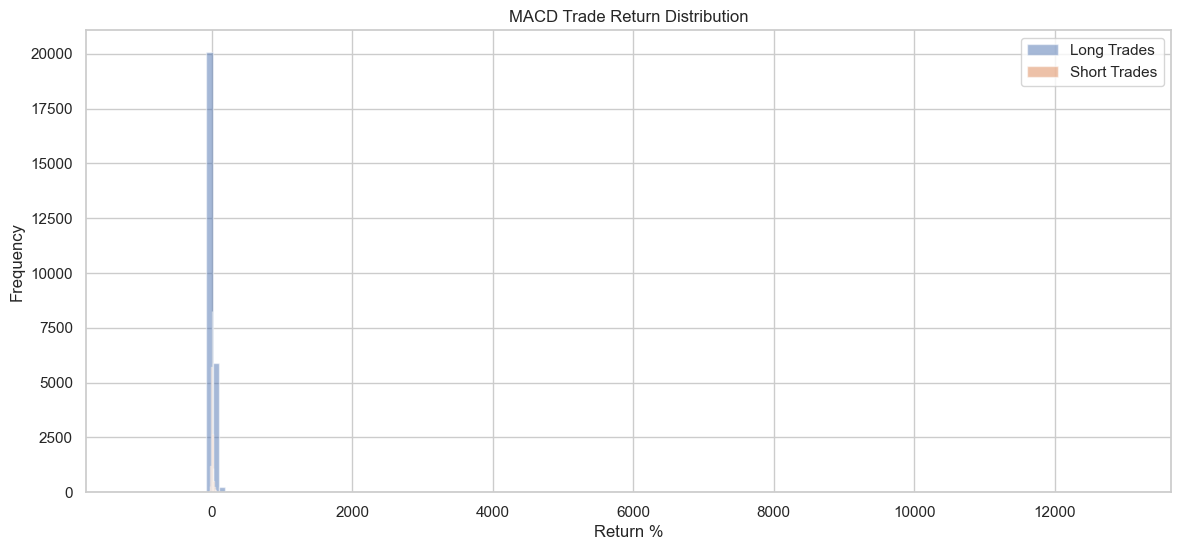

In [20]:
# ============================================================
# BLOCK 5.2 - HISTOGRAM
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.hist(
    macd_longs["Return %"],
    bins=150,
    alpha=0.5,
    label="Long Trades"
)

plt.hist(
    macd_shorts["Return %"],
    bins=150,
    alpha=0.5,
    label="Short Trades"
)

plt.title("MACD Trade Return Distribution")

plt.xlabel("Return %")
plt.ylabel("Frequency")

plt.legend()

plt.show()

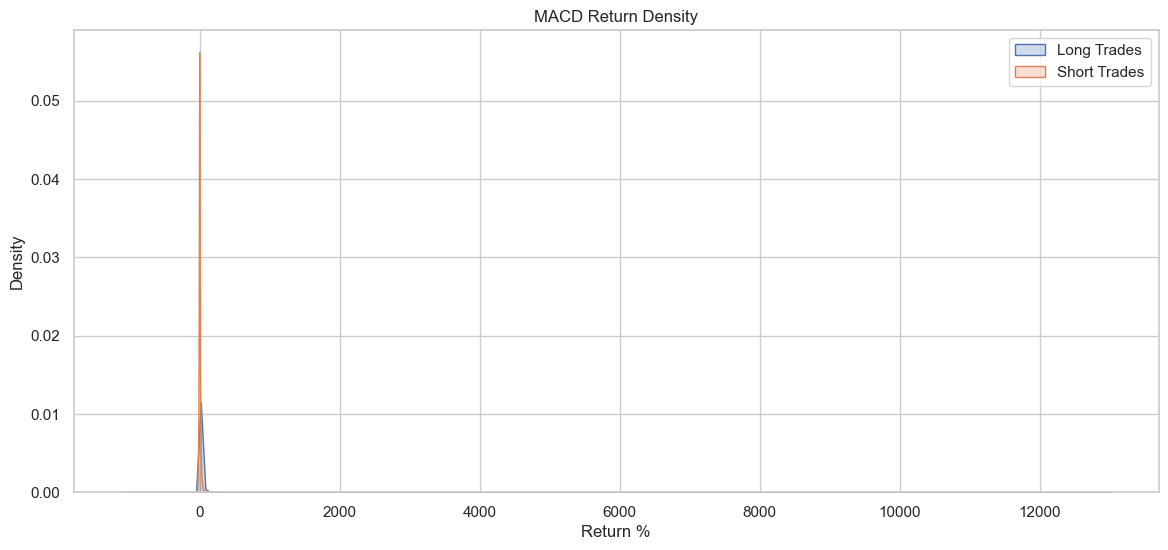

In [21]:
# ============================================================
# BLOCK 5.3 - KDE DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 6))

sns.kdeplot(
    macd_longs["Return %"],
    label="Long Trades",
    fill=True
)

sns.kdeplot(
    macd_shorts["Return %"],
    label="Short Trades",
    fill=True
)

plt.title("MACD Return Density")

plt.xlabel("Return %")

plt.legend()

plt.show()

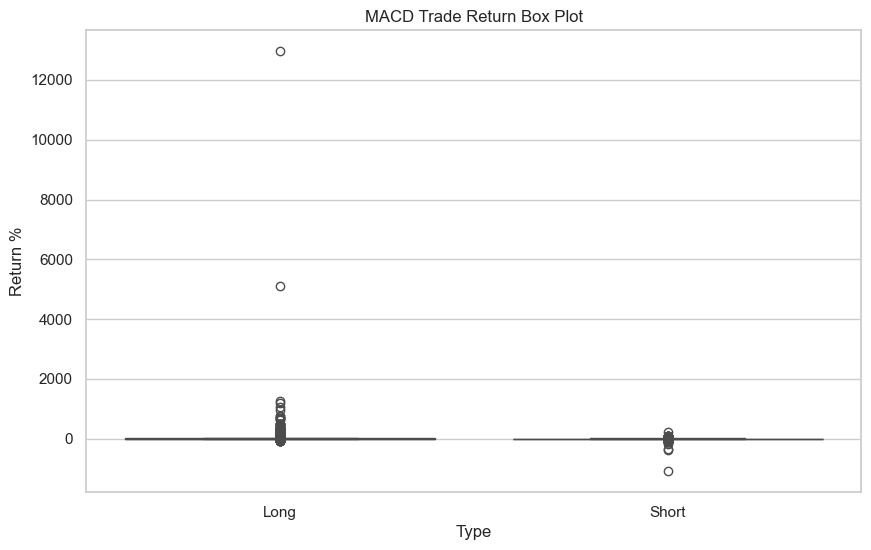

In [22]:
# ============================================================
# BLOCK 5.4 - BOX PLOT
# ============================================================

plot_df = pd.concat([

    pd.DataFrame({
        "Type": "Long",
        "Return": macd_longs["Return %"]
    }),

    pd.DataFrame({
        "Type": "Short",
        "Return": macd_shorts["Return %"]
    })

])

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Type",
    y="Return",
    data=plot_df
)

plt.title("MACD Trade Return Box Plot")

plt.ylabel("Return %")

plt.show()

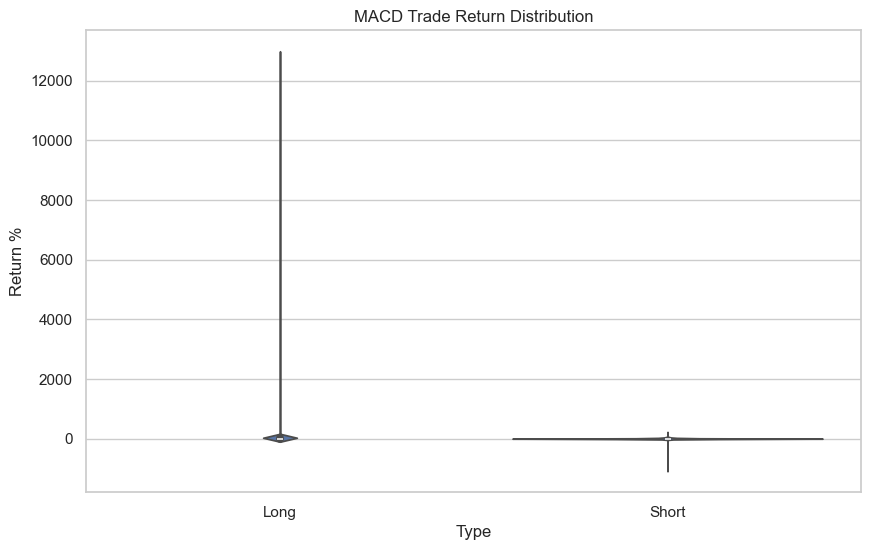

In [23]:
# ============================================================
# BLOCK 5.5 - VIOLIN PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    x="Type",
    y="Return",
    data=plot_df
)

plt.title("MACD Trade Return Distribution")

plt.ylabel("Return %")

plt.show()

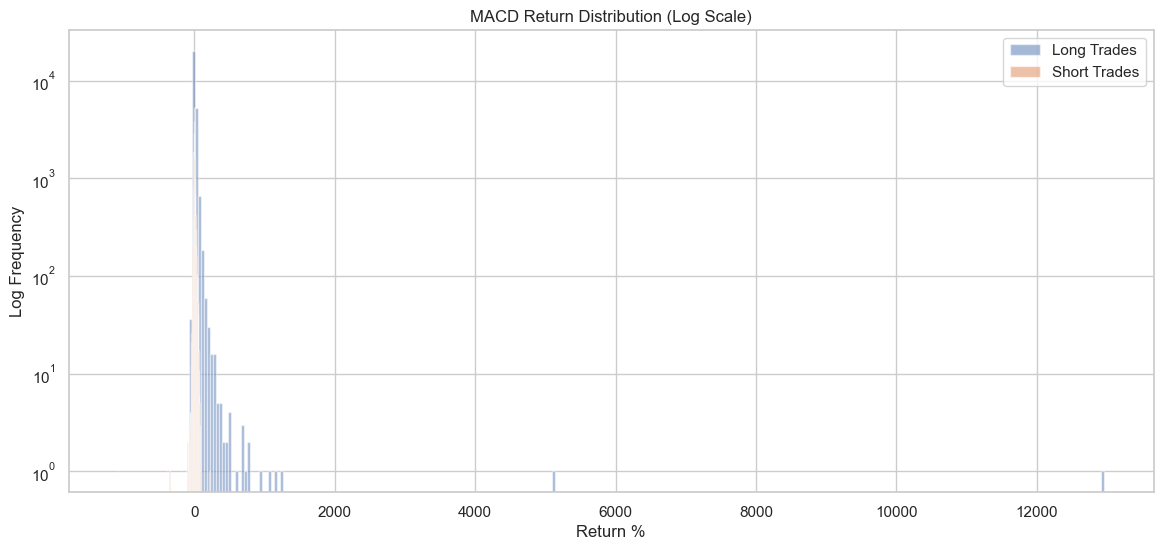

In [24]:
# ============================================================
# BLOCK 5.6 - TAIL ANALYSIS HISTOGRAM
# ============================================================

plt.figure(figsize=(14, 6))

plt.hist(
    macd_longs["Return %"],
    bins=300,
    alpha=0.5,
    label="Long Trades"
)

plt.hist(
    macd_shorts["Return %"],
    bins=300,
    alpha=0.5,
    label="Short Trades"
)

plt.yscale("log")

plt.title("MACD Return Distribution (Log Scale)")

plt.xlabel("Return %")
plt.ylabel("Log Frequency")

plt.legend()

plt.show()

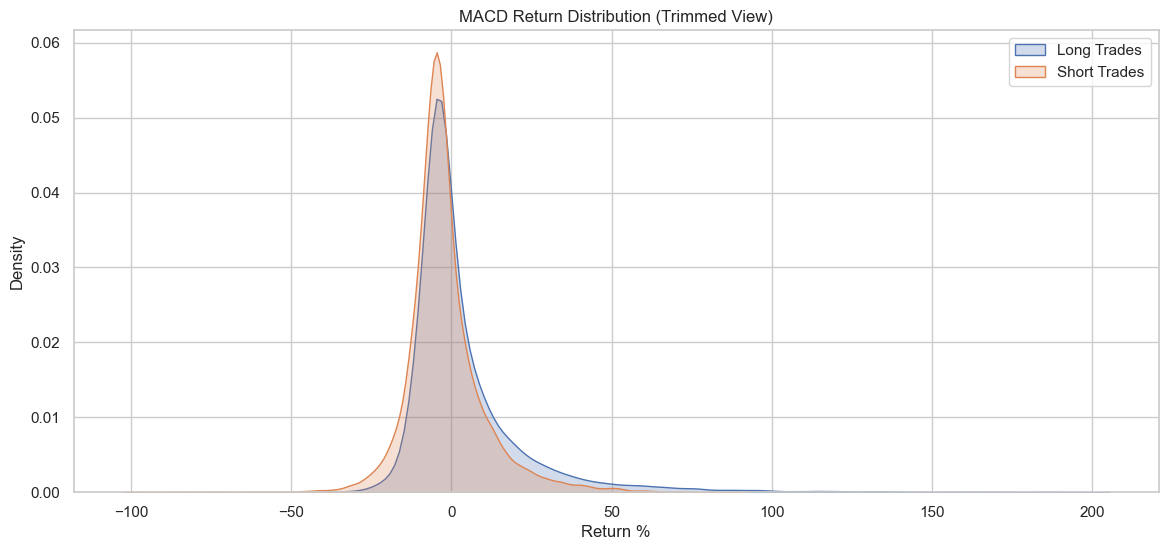

In [25]:
# ============================================================
# BLOCK 5.7 - TRIMMED VISUALIZATION
# ============================================================

long_trim = macd_longs[
    (macd_longs["Return %"] >= -100) &
    (macd_longs["Return %"] <= 200)
]

short_trim = macd_shorts[
    (macd_shorts["Return %"] >= -100) &
    (macd_shorts["Return %"] <= 200)
]

plt.figure(figsize=(14,6))

sns.kdeplot(
    long_trim["Return %"],
    label="Long Trades",
    fill=True
)

sns.kdeplot(
    short_trim["Return %"],
    label="Short Trades",
    fill=True
)

plt.title(
    "MACD Return Distribution (Trimmed View)"
)

plt.xlabel("Return %")

plt.legend()

plt.show()

In [26]:
# ============================================================
# SAVE MACD RESEARCH DATA
# ============================================================

output_folder = "research_outputs"

os.makedirs(
    output_folder,
    exist_ok=True
)

macd_trades.to_excel(
    f"{output_folder}/MACD_Trades.xlsx",
    index=False
)

macd_stats.to_excel(
    f"{output_folder}/MACD_Statistics.xlsx",
    index=False
)

long_robust.to_excel(
    f"{output_folder}/MACD_Long_Robust.xlsx",
    index=False
)

short_robust.to_excel(
    f"{output_folder}/MACD_Short_Robust.xlsx",
    index=False
)

print(
    "✅ MACD research outputs saved"
)

✅ MACD research outputs saved


In [27]:
# ============================================================
# HURST EXPONENT
# ============================================================

def calculate_hurst(series, max_lag=100):

    lags = range(2, max_lag)

    tau = [
        np.sqrt(
            np.std(
                series[lag:] - series[:-lag]
            )
        )
        for lag in lags
    ]

    poly = np.polyfit(
        np.log(lags),
        np.log(tau),
        1
    )

    return poly[0] * 2.0


# ============================================================
# MEAN REVERSION STRATEGY
# ============================================================

class MeanReversionStrategy(
    BaseResearchStrategy
):

    def __init__(self):

        super().__init__(
            "Mean Reversion"
        )

    def generate_signals(
        self,
        data
    ):

        price = data["Price"]

        # ------------------------------------
        # HURST FILTER
        # ------------------------------------

        try:

            hurst = calculate_hurst(
                price.values
            )

        except:

            data["Signal"] = 0

            data["Long Exit"] = False
            data["Short Exit"] = False

            return data

        # ------------------------------------
        # NOT MEAN REVERTING
        # ------------------------------------

        if hurst >= 0.50:

            data["Signal"] = 0

            data["Long Exit"] = False
            data["Short Exit"] = False

            return data

        # ------------------------------------
        # Z SCORE
        # ------------------------------------

        lookback = 20

        rolling_mean = (
            price
            .rolling(lookback)
            .mean()
        )

        rolling_std = (
            price
            .rolling(lookback)
            .std()
        )

        zscore = (
            price
            - rolling_mean
        ) / rolling_std

        data["Signal"] = 0

        # ------------------------------------
        # LONG ENTRY
        # ------------------------------------

        data.loc[
            zscore < -2,
            "Signal"
        ] = 1

        # ------------------------------------
        # SHORT ENTRY
        # ------------------------------------

        data.loc[
            zscore > 2,
            "Signal"
        ] = -1

        # ------------------------------------
        # EXITS
        # ------------------------------------

        data["Long Exit"] = (
            zscore > 0
        )

        data["Short Exit"] = (
            zscore < 0
        )

        return data


print(
    "✅ Mean Reversion Strategy Loaded"
)

✅ Mean Reversion Strategy Loaded


In [28]:
# ============================================================
# TEST MEAN REVERSION
# ============================================================

sample_ticker = list(
    data_dict.keys()
)[0]

sample_df = data_dict[
    sample_ticker
]

mr_strategy = (
    MeanReversionStrategy()
)

mr_trades_sample = (
    mr_strategy.generate_trades(
        sample_ticker,
        sample_df
    )
)

print(
    f"\nTicker: {sample_ticker}"
)

print(
    f"Trades Generated: {len(mr_trades_sample)}"
)

display(
    mr_trades_sample.head(10)
)


Ticker: 360ONE.NS
Trades Generated: 44


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,360ONE.NS,Mean Reversion,2019-12-11,2020-01-06,Long,233.7542,244.5942,4.637340,26
1,360ONE.NS,Mean Reversion,2020-01-17,2020-03-02,Short,250.8738,309.9712,-23.556626,45
2,360ONE.NS,Mean Reversion,2020-03-13,2020-04-16,Long,232.3746,199.1783,-14.285701,34
3,360ONE.NS,Mean Reversion,2020-06-04,2020-07-02,Short,193.9913,211.6269,-9.090918,28
4,360ONE.NS,Mean Reversion,2020-08-03,2020-09-01,Short,222.2082,220.0730,0.960903,29
5,360ONE.NS,Mean Reversion,2020-10-09,2020-11-06,Long,203.1931,195.8068,-3.635108,28
6,360ONE.NS,Mean Reversion,2020-11-13,2020-12-22,Short,202.9889,213.0953,-4.978809,39
7,360ONE.NS,Mean Reversion,2021-01-14,2021-01-25,Short,232.8781,222.3416,4.524464,11
8,360ONE.NS,Mean Reversion,2021-02-08,2021-03-02,Short,248.7689,258.2382,-3.806474,22
9,360ONE.NS,Mean Reversion,2021-04-01,2021-04-13,Short,273.5934,255.7469,6.522992,12


In [29]:
# ============================================================
# BUILD MEAN REVERSION DATASET
# ============================================================

mr_strategy = MeanReversionStrategy()

mr_trades = build_strategy_dataset(
    mr_strategy,
    data_dict
)

print(
    f"\n✅ Total Mean Reversion Trades: {len(mr_trades):,}"
)

display(
    mr_trades.head()
)


🚀 Running Mean Reversion



Mean Reversion: 100%|███████████████████████████████████| 493/493 [05:22<00:00,  1.53it/s]


✅ Total Mean Reversion Trades: 42,465


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,360ONE.NS,Mean Reversion,2019-12-11,2020-01-06,Long,233.7542,244.5942,4.637340,26
1,360ONE.NS,Mean Reversion,2020-01-17,2020-03-02,Short,250.8738,309.9712,-23.556626,45
2,360ONE.NS,Mean Reversion,2020-03-13,2020-04-16,Long,232.3746,199.1783,-14.285701,34
3,360ONE.NS,Mean Reversion,2020-06-04,2020-07-02,Short,193.9913,211.6269,-9.090918,28
4,360ONE.NS,Mean Reversion,2020-08-03,2020-09-01,Short,222.2082,220.0730,0.960903,29


In [30]:
print(mr_trades.shape)

mr_trades.describe(
    include="all"
)

(42465, 9)


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
count,42465,42465,42465,42465,42465,42465.000000,42465.000000,42465.000000,42465.000000
unique,323,1,NaN,NaN,2,NaN,NaN,NaN,NaN
top,INDIACEM.NS,Mean Reversion,NaN,NaN,Short,NaN,NaN,NaN,NaN
freq,237,42465,NaN,NaN,24070,NaN,NaN,NaN,NaN
mean,NaN,NaN,2015-12-17 11:04:10.003532,2016-01-09 15:38:30.052984,NaN,799.784447,806.726188,-0.975344,23.190510
min,NaN,NaN,2000-01-31 00:00:00,2000-02-07 00:00:00,NaN,0.014900,0.016000,-1285.898848,1.000000
25%,NaN,NaN,2010-07-09 00:00:00,2010-07-29 00:00:00,NaN,45.934400,46.276000,-3.678942,10.000000
50%,NaN,NaN,2016-11-01 00:00:00,2016-11-17 00:00:00,NaN,161.408800,163.282700,2.083316,20.000000
75%,NaN,NaN,2022-01-19 00:00:00,2022-02-03 00:00:00,NaN,596.820000,601.201400,5.364014,30.000000
max,NaN,NaN,2026-03-27 00:00:00,2026-04-02 00:00:00,NaN,57659.272300,56278.871600,499.002574,1840.000000


In [31]:
# ============================================================
# MEAN REVERSION STATISTICS
# ============================================================

mr_stats = trade_statistics(
    mr_trades
)

display(
    mr_stats
)

,Metric,Value
0,Total Trades,42465.000000
1,Win Rate,61.928647
2,Loss Rate,38.010126
3,Average Trade,-0.975344
4,Median Trade,2.083316
5,Average Winner,5.420033
6,Average Loser,-11.396692
7,Largest Winner,499.002574
8,Largest Loser,-1285.898848
9,Profit Factor,0.774846


In [33]:
# ============================================================
# SPLIT LONGS / SHORTS
# ============================================================

mr_longs = mr_trades[
    mr_trades["Position"] == "Long"
].copy()

mr_shorts = mr_trades[
    mr_trades["Position"] == "Short"
].copy()

print(
    "Long Trades:",
    len(mr_longs)
)

print(
    "Short Trades:",
    len(mr_shorts)
)

Long Trades: 18395
Short Trades: 24070


In [34]:
mr_long_stats = trade_statistics(mr_longs)
mr_short_stats = trade_statistics(mr_shorts)

print("\nMEAN REVERSION LONGS\n")
print(mr_long_stats)

print("\nMEAN REVERSION SHORTS\n")
print(mr_short_stats)


MEAN REVERSION LONGS

                  Metric         Value
0           Total Trades  18395.000000
1               Win Rate     66.017940
2              Loss Rate     33.927698
3          Average Trade      0.938876
4           Median Trade      2.579919
5         Average Winner      5.797134
6          Average Loser     -8.513023
7         Largest Winner    499.002574
8          Largest Loser    -84.761197
9          Profit Factor      1.325065
10          Payoff Ratio      0.680972
11            Expectancy      0.938876
12  Average Holding Days     21.513292
13   Median Holding Days     18.000000
14  Maximum Holding Days   1840.000000
15               Std Dev     10.733613
16              Skewness      7.064227
17              Kurtosis    351.033291

MEAN REVERSION SHORTS

                  Metric         Value
0           Total Trades  24070.000000
1               Win Rate     58.803490
2              Loss Rate     41.130037
3          Average Trade     -2.438247
4           Media

In [35]:
long_robust_mr = robust_trade_statistics(
    mr_longs
)

short_robust_mr = robust_trade_statistics(
    mr_shorts
)

print("\nMEAN REVERSION LONGS\n")
print(long_robust_mr)

print("\nMEAN REVERSION SHORTS\n")
print(short_robust_mr)


MEAN REVERSION LONGS

        Metric         Raw  Winsorized
0  Mean Return    0.938876    0.934937
1      Std Dev   10.733613    8.810770
2     Skewness    7.064227   -1.343298
3     Kurtosis  351.033291    3.145612

MEAN REVERSION SHORTS

        Metric          Raw  Winsorized
0  Mean Return    -2.438247   -1.953116
1      Std Dev    20.291533   12.262453
2     Skewness   -23.173718   -2.312565
3     Kurtosis  1101.280712    6.886927


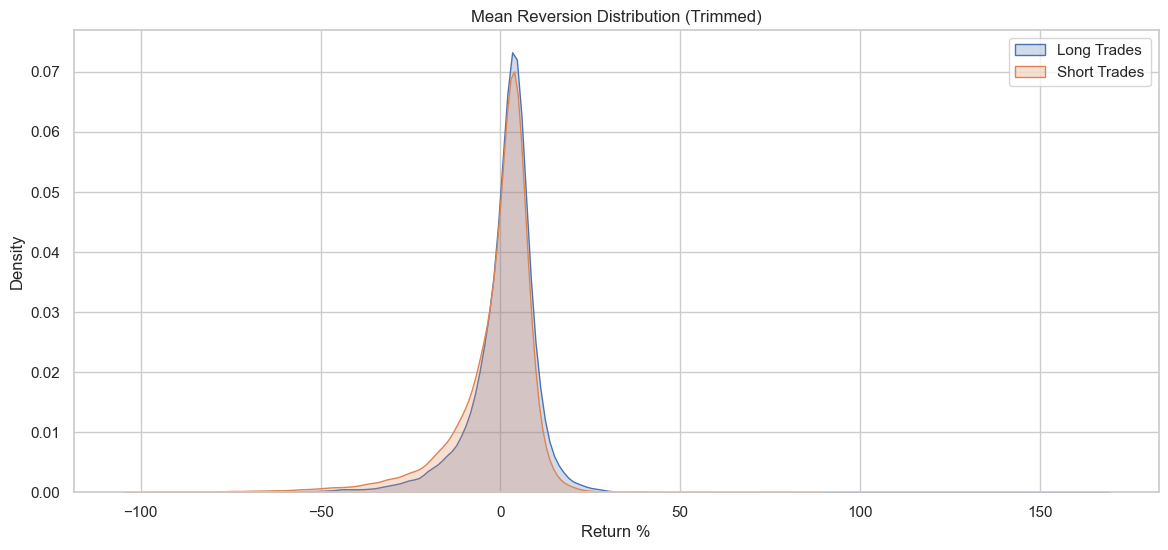

In [36]:
mr_long_trim = mr_longs[
    (mr_longs["Return %"] >= -100)
    &
    (mr_longs["Return %"] <= 200)
]

mr_short_trim = mr_shorts[
    (mr_shorts["Return %"] >= -100)
    &
    (mr_shorts["Return %"] <= 200)
]

plt.figure(figsize=(14,6))

sns.kdeplot(
    mr_long_trim["Return %"],
    label="Long Trades",
    fill=True
)

sns.kdeplot(
    mr_short_trim["Return %"],
    label="Short Trades",
    fill=True
)

plt.title(
    "Mean Reversion Distribution (Trimmed)"
)

plt.xlabel("Return %")

plt.legend()

plt.show()

In [37]:
# ============================================================
# BOLLINGER BREAKOUT STRATEGY
# ============================================================

class BollingerBreakoutStrategy(
    BaseResearchStrategy
):

    def __init__(self):

        super().__init__(
            "Bollinger Breakout"
        )

    def generate_signals(
        self,
        data
    ):

        price = data["Price"]

        sma = (
            price
            .rolling(20)
            .mean()
        )

        std = (
            price
            .rolling(20)
            .std()
        )

        upper = sma + 2 * std
        lower = sma - 2 * std

        data["Signal"] = 0

        # ----------------------------------
        # LONG ENTRY
        # ----------------------------------

        data.loc[
            price > upper,
            "Signal"
        ] = 1

        # ----------------------------------
        # SHORT ENTRY
        # ----------------------------------

        data.loc[
            price < lower,
            "Signal"
        ] = -1

        # ----------------------------------
        # EXITS
        # ----------------------------------

        data["Long Exit"] = (
            price < sma
        )

        data["Short Exit"] = (
            price > sma
        )

        return data


print(
    "✅ Bollinger Breakout Strategy Loaded"
)

✅ Bollinger Breakout Strategy Loaded


In [38]:
sample_ticker = list(data_dict.keys())[0]

bb_strategy = BollingerBreakoutStrategy()

bb_sample = bb_strategy.generate_trades(
    sample_ticker,
    data_dict[sample_ticker]
)

print(
    f"Trades Generated: {len(bb_sample)}"
)

display(
    bb_sample.head(10)
)

Trades Generated: 44


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,360ONE.NS,Bollinger Breakout,2019-12-11,2020-01-06,Short,233.7542,244.5942,-4.637340,26
1,360ONE.NS,Bollinger Breakout,2020-01-17,2020-03-02,Long,250.8738,309.9712,23.556626,45
2,360ONE.NS,Bollinger Breakout,2020-03-13,2020-04-16,Short,232.3746,199.1783,14.285701,34
3,360ONE.NS,Bollinger Breakout,2020-06-04,2020-07-02,Long,193.9913,211.6269,9.090918,28
4,360ONE.NS,Bollinger Breakout,2020-08-03,2020-09-01,Long,222.2082,220.0730,-0.960903,29
5,360ONE.NS,Bollinger Breakout,2020-10-09,2020-11-06,Short,203.1931,195.8068,3.635108,28
6,360ONE.NS,Bollinger Breakout,2020-11-13,2020-12-22,Long,202.9889,213.0953,4.978809,39
7,360ONE.NS,Bollinger Breakout,2021-01-14,2021-01-25,Long,232.8781,222.3416,-4.524464,11
8,360ONE.NS,Bollinger Breakout,2021-02-08,2021-03-02,Long,248.7689,258.2382,3.806474,22
9,360ONE.NS,Bollinger Breakout,2021-04-01,2021-04-13,Long,273.5934,255.7469,-6.522992,12


In [39]:
print("Mean Reversion Trades:", len(mr_trades))

print("Bollinger Sample Trades:", len(bb_sample))

Mean Reversion Trades: 42465
Bollinger Sample Trades: 44


In [40]:
# ============================================================
# TRUE BOLLINGER BREAKOUT STRATEGY
# ============================================================

class BollingerBreakoutStrategy(
    BaseResearchStrategy
):

    def __init__(self):

        super().__init__(
            "Bollinger Breakout"
        )

    def generate_signals(
        self,
        data
    ):

        price = data["Price"]

        # =====================================
        # TREND FILTER
        # =====================================

        sma200 = (
            price
            .rolling(200)
            .mean()
        )

        # =====================================
        # BOLLINGER BANDS
        # =====================================

        sma20 = (
            price
            .rolling(20)
            .mean()
        )

        std20 = (
            price
            .rolling(20)
            .std()
        )

        upper_band = (
            sma20
            + 2 * std20
        )

        lower_band = (
            sma20
            - 2 * std20
        )

        # =====================================
        # ENTRY SIGNALS
        # =====================================

        data["Signal"] = 0

        long_entry = (

            (price > upper_band)

            &

            (
                price.shift(1)
                <= upper_band.shift(1)
            )

            &

            (
                price > sma200
            )

        )

        short_entry = (

            (price < lower_band)

            &

            (
                price.shift(1)
                >= lower_band.shift(1)
            )

            &

            (
                price < sma200
            )

        )

        data.loc[
            long_entry,
            "Signal"
        ] = 1

        data.loc[
            short_entry,
            "Signal"
        ] = -1

        # =====================================
        # BREAKOUT EXITS
        # =====================================

        lowest_10 = (

            data["Low"]
            .rolling(10)
            .min()
            .shift(1)

        )

        highest_10 = (

            data["High"]
            .rolling(10)
            .max()
            .shift(1)

        )

        data["Long Exit"] = (
            data["Low"]
            < lowest_10
        )

        data["Short Exit"] = (
            data["High"]
            > highest_10
        )

        return data


print(
    "✅ True Bollinger Breakout Loaded"
)

✅ True Bollinger Breakout Loaded


In [41]:
sample_ticker = list(
    data_dict.keys()
)[0]

bb_strategy = (
    BollingerBreakoutStrategy()
)

bb_sample = (
    bb_strategy.generate_trades(
        sample_ticker,
        data_dict[sample_ticker]
    )
)

print(
    f"\nTicker: {sample_ticker}"
)

print(
    f"Trades Generated: {len(bb_sample)}"
)

display(
    bb_sample.head(10)
)


Ticker: 360ONE.NS
Trades Generated: 30


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,360ONE.NS,Bollinger Breakout,2020-08-19,2020-09-01,Long,240.0513,220.0730,-8.322506,13
1,360ONE.NS,Bollinger Breakout,2020-10-09,2020-11-13,Short,203.1931,202.9889,0.100524,35
2,360ONE.NS,Bollinger Breakout,2020-12-11,2020-12-23,Long,227.6206,214.4607,-5.781488,12
3,360ONE.NS,Bollinger Breakout,2021-01-14,2021-01-25,Long,232.8781,222.3416,-4.524464,11
4,360ONE.NS,Bollinger Breakout,2021-02-08,2021-02-24,Long,248.7689,252.4290,1.471295,16
5,360ONE.NS,Bollinger Breakout,2021-04-01,2021-04-13,Long,273.5934,255.7469,-6.522992,12
6,360ONE.NS,Bollinger Breakout,2021-07-06,2021-08-24,Long,268.3684,342.0863,27.468897,49
7,360ONE.NS,Bollinger Breakout,2021-09-13,2021-09-22,Long,386.2554,347.6637,-9.991245,9
8,360ONE.NS,Bollinger Breakout,2021-10-19,2021-10-25,Long,377.6920,349.5229,-7.458231,6
9,360ONE.NS,Bollinger Breakout,2022-01-12,2022-01-25,Long,364.7430,342.7284,-6.035641,13


In [42]:
# ============================================================
# BUILD BREAKOUT DATASET
# ============================================================

bb_strategy = BollingerBreakoutStrategy()

breakout_trades = build_strategy_dataset(
    bb_strategy,
    data_dict
)

print(
    f"\n✅ Total Breakout Trades: {len(breakout_trades):,}"
)

display(
    breakout_trades.head()
)


🚀 Running Bollinger Breakout



Bollinger Breakout: 100%|███████████████████████████████| 493/493 [05:39<00:00,  1.45it/s]


✅ Total Breakout Trades: 42,526


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,360ONE.NS,Bollinger Breakout,2020-08-19,2020-09-01,Long,240.0513,220.0730,-8.322506,13
1,360ONE.NS,Bollinger Breakout,2020-10-09,2020-11-13,Short,203.1931,202.9889,0.100524,35
2,360ONE.NS,Bollinger Breakout,2020-12-11,2020-12-23,Long,227.6206,214.4607,-5.781488,12
3,360ONE.NS,Bollinger Breakout,2021-01-14,2021-01-25,Long,232.8781,222.3416,-4.524464,11
4,360ONE.NS,Bollinger Breakout,2021-02-08,2021-02-24,Long,248.7689,252.4290,1.471295,16


In [43]:
print(breakout_trades.shape)

breakout_trades.describe(
    include="all"
)

(42526, 9)


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
count,42526,42526,42526,42526,42526,42526.000000,42526.000000,42526.000000,42526.000000
unique,493,1,NaN,NaN,2,NaN,NaN,NaN,NaN
top,MARICO.NS,Bollinger Breakout,NaN,NaN,Long,NaN,NaN,NaN,NaN
freq,166,42526,NaN,NaN,27022,NaN,NaN,NaN,NaN
mean,NaN,NaN,2016-01-30 20:49:33.729012,2016-02-27 04:47:33.181583,NaN,907.503233,916.573027,2.023893,27.331938
min,NaN,NaN,2000-10-09 00:00:00,2000-10-18 00:00:00,NaN,0.024500,0.023700,-499.002574,1.000000
25%,NaN,NaN,2010-10-07 00:00:00,2010-10-29 00:00:00,NaN,49.574575,50.169300,-5.760688,14.000000
50%,NaN,NaN,2016-10-25 00:00:00,2016-11-10 00:00:00,NaN,163.535000,165.117150,-1.562501,21.000000
75%,NaN,NaN,2022-01-14 00:00:00,2022-01-28 00:00:00,NaN,594.392575,600.632350,4.988904,35.000000
max,NaN,NaN,2026-03-24 00:00:00,2026-04-02 00:00:00,NaN,161093.632300,157878.753600,10057.728051,1726.000000


In [44]:
bb_stats = trade_statistics(
    breakout_trades
)

print("\nBREAKOUT STATISTICS\n")

print(bb_stats)


BREAKOUT STATISTICS

                  Metric         Value
0           Total Trades  42526.000000
1               Win Rate     41.877910
2              Loss Rate     58.075060
3          Average Trade      2.023893
4           Median Trade     -1.562501
5         Average Winner     13.191025
6          Average Loser     -6.027084
7         Largest Winner  10057.728051
8          Largest Loser   -499.002574
9          Profit Factor      1.578217
10          Payoff Ratio      2.188625
11            Expectancy      2.023893
12  Average Holding Days     27.331938
13   Median Holding Days     21.000000
14  Maximum Holding Days   1726.000000
15               Std Dev     52.479619
16              Skewness    166.389032
17              Kurtosis  31712.849821


In [45]:
bb_longs = breakout_trades[
    breakout_trades["Position"] == "Long"
].copy()

bb_shorts = breakout_trades[
    breakout_trades["Position"] == "Short"
].copy()

print("Long Trades :", len(bb_longs))
print("Short Trades:", len(bb_shorts))

Long Trades : 27022
Short Trades: 15504


In [46]:
bb_long_stats = trade_statistics(
    bb_longs
)

bb_short_stats = trade_statistics(
    bb_shorts
)

print("\nBREAKOUT LONGS\n")
print(bb_long_stats)

print("\nBREAKOUT SHORTS\n")
print(bb_short_stats)


BREAKOUT LONGS

                  Metric         Value
0           Total Trades  27022.000000
1               Win Rate     44.115906
2              Loss Rate     55.865591
3          Average Trade      3.499392
4           Median Trade     -1.172074
5         Average Winner     14.980996
6          Average Loser     -5.566236
7         Largest Winner  10057.728051
8          Largest Loser    -78.775511
9          Profit Factor      2.125347
10          Payoff Ratio      2.691405
11            Expectancy      3.499392
12  Average Holding Days     28.372992
13   Median Holding Days     22.000000
14  Maximum Holding Days   1726.000000
15               Std Dev     65.118189
16              Skewness    137.022464
17              Kurtosis  21040.526450

BREAKOUT SHORTS

                  Metric         Value
0           Total Trades  15504.000000
1               Win Rate     37.977296
2              Loss Rate     61.925955
3          Average Trade     -0.547761
4           Median Trade     

In [47]:
bb_long_robust = robust_trade_statistics(
    bb_longs
)

bb_short_robust = robust_trade_statistics(
    bb_shorts
)

print("\nBREAKOUT LONGS ROBUST\n")
print(bb_long_robust)

print("\nBREAKOUT SHORTS ROBUST\n")
print(bb_short_robust)


BREAKOUT LONGS ROBUST

        Metric           Raw  Winsorized
0  Mean Return      3.499392    2.540793
1      Std Dev     65.118189   13.514163
2     Skewness    137.022464    2.231898
3     Kurtosis  21040.526450    6.446368

BREAKOUT SHORTS ROBUST

        Metric         Raw  Winsorized
0  Mean Return   -0.547761   -0.517270
1      Std Dev   12.384833   10.556655
2     Skewness   -5.093825    1.304252
3     Kurtosis  234.329511    3.193328


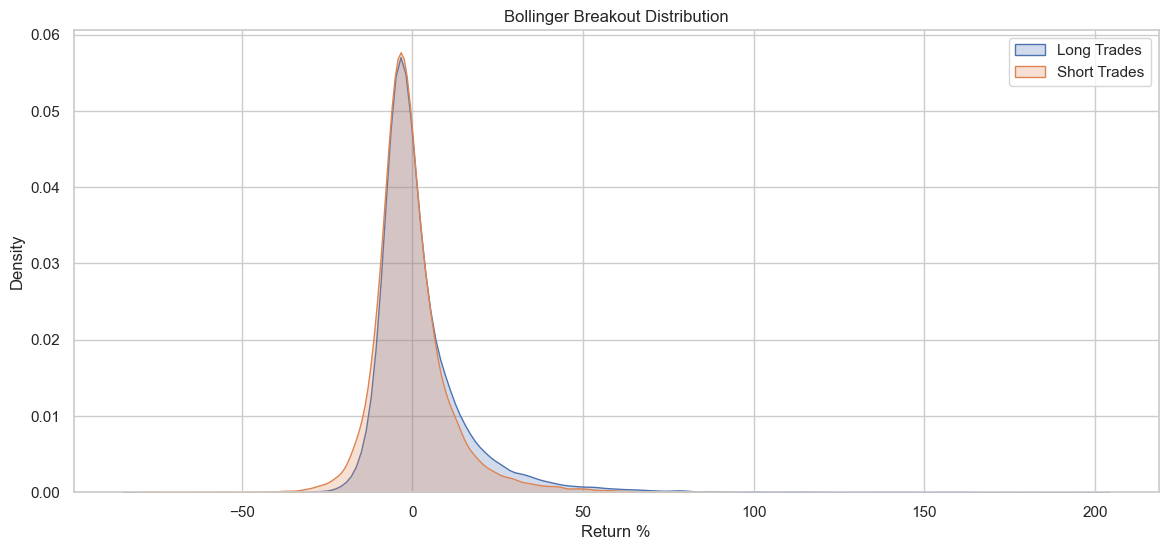

In [48]:
bb_long_trim = bb_longs[
    (bb_longs["Return %"] >= -100)
    &
    (bb_longs["Return %"] <= 200)
]

bb_short_trim = bb_shorts[
    (bb_shorts["Return %"] >= -100)
    &
    (bb_shorts["Return %"] <= 200)
]

plt.figure(figsize=(14,6))

sns.kdeplot(
    bb_long_trim["Return %"],
    fill=True,
    label="Long Trades"
)

sns.kdeplot(
    bb_short_trim["Return %"],
    fill=True,
    label="Short Trades"
)

plt.title(
    "Bollinger Breakout Distribution"
)

plt.xlabel("Return %")

plt.legend()

plt.show()

In [49]:
# ============================================================
# INSTITUTIONAL QUALITY CONTROL
# ============================================================

MIN_PRICE = 10
MAX_HOLD_DAYS = 365

def clean_trade_dataset(df):

    clean_df = df.copy()

    before = len(clean_df)

    clean_df = clean_df[
        clean_df["Entry Price"] >= MIN_PRICE
    ]

    clean_df = clean_df[
        clean_df["Holding Days"] <= MAX_HOLD_DAYS
    ]

    after = len(clean_df)

    print(
        f"Removed {before-after:,} trades"
    )

    print(
        f"Remaining {after:,} trades"
    )

    return clean_df


print(
    "✅ Quality Control Loaded"
)

✅ Quality Control Loaded


In [50]:
# ============================================================
# CLEAN DATASETS
# ============================================================

macd_clean = clean_trade_dataset(
    macd_trades
)

mr_clean = clean_trade_dataset(
    mr_trades
)

breakout_clean = clean_trade_dataset(
    breakout_trades
)

Removed 3,014 trades
Remaining 43,719 trades
Removed 2,452 trades
Remaining 40,013 trades
Removed 2,325 trades
Remaining 40,201 trades


In [51]:
print("\nMACD")
print(len(macd_trades))
print(len(macd_clean))

print("\nMEAN REVERSION")
print(len(mr_trades))
print(len(mr_clean))

print("\nBREAKOUT")
print(len(breakout_trades))
print(len(breakout_clean))


MACD
46733
43719

MEAN REVERSION
42465
40013

BREAKOUT
42526
40201


In [52]:
print("\nMACD")
print(
    macd_clean["Return %"]
    .nlargest(10)
)

print("\nMEAN REVERSION")
print(
    mr_clean["Return %"]
    .nlargest(10)
)

print("\nBREAKOUT")
print(
    breakout_clean["Return %"]
    .nlargest(10)
)


MACD
18504    1177.987110
1503      759.993682
42024     708.080966
18840     687.028475
184       666.650735
17960     502.725854
25647     462.500083
13482     416.292121
1232      370.840899
25394     368.233440
Name: Return %, dtype: float64

MEAN REVERSION
7007     499.002574
27343    387.068945
3563     126.884401
37241     85.053407
16563     77.963491
32415     77.712694
15406     76.922505
27340     75.643519
9954      74.835207
39579     74.807693
Name: Return %, dtype: float64

BREAKOUT
16823    1164.800546
38184     627.171453
23290     456.049859
17113     423.241566
37724     396.450454
10015     374.195075
16340     361.801007
33949     249.812311
22577     240.281917
4053      238.963154
Name: Return %, dtype: float64


In [53]:
# ============================================================
# INSTITUTIONAL STRATEGY SUMMARY
# ============================================================

from scipy.stats import skew, kurtosis

def strategy_summary(trades_df):

    returns = trades_df["Return %"]

    winners = returns[returns > 0]
    losers = returns[returns <= 0]

    summary = {

        # ----------------------------------
        # TRADE METRICS
        # ----------------------------------

        "Total Trades": len(trades_df),

        "Win Rate %":
            len(winners) / len(trades_df) * 100,

        "Avg Winner %":
            winners.mean(),

        "Avg Loser %":
            losers.mean(),

        "Payoff Ratio":
            winners.mean() / abs(losers.mean())
            if len(losers) > 0 else np.nan,

        "Profit Factor":
            winners.sum() / abs(losers.sum())
            if losers.sum() != 0 else np.nan,

        "Expectancy %":
            returns.mean(),

        # ----------------------------------
        # DISTRIBUTION
        # ----------------------------------

        "Mean Return %":
            returns.mean(),

        "Median Return %":
            returns.median(),

        "Std Dev":
            returns.std(),

        "Skew":
            skew(returns),

        "Kurtosis":
            kurtosis(returns),

        # ----------------------------------
        # HOLDING PERIOD
        # ----------------------------------

        "Avg Hold Days":
            trades_df["Holding Days"].mean(),

        "Median Hold Days":
            trades_df["Holding Days"].median(),

        # ----------------------------------
        # TAIL METRICS
        # ----------------------------------

        "1% Percentile":
            returns.quantile(0.01),

        "5% Percentile":
            returns.quantile(0.05),

        "95% Percentile":
            returns.quantile(0.95),

        "99% Percentile":
            returns.quantile(0.99),

        "Max Winner %":
            returns.max(),

        "Max Loser %":
            returns.min()

    }

    return pd.Series(summary)

print("✅ Strategy Summary Loaded")

✅ Strategy Summary Loaded


In [54]:
# ============================================================
# BUILD COMPARISON TABLE
# ============================================================

comparison_table = pd.concat(

    [

        strategy_summary(
            macd_clean
        ),

        strategy_summary(
            mr_clean
        ),

        strategy_summary(
            breakout_clean
        )

    ],

    axis=1

)

comparison_table.columns = [

    "MACD",
    "Mean Reversion",
    "Breakout"

]

comparison_table = comparison_table.round(2)

comparison_table

,MACD,Mean Reversion,Breakout
Total Trades,43719.00,40013.00,40201.00
Win Rate %,36.63,62.23,41.74
Avg Winner %,16.61,5.31,11.86
Avg Loser %,-6.82,-10.76,-5.90
Payoff Ratio,2.44,0.49,2.01
Profit Factor,1.41,0.81,1.44
Expectancy %,1.77,-0.76,1.51
Mean Return %,1.77,-0.76,1.51
Median Return %,-2.73,2.10,-1.57
Std Dev,21.20,14.45,16.20


In [55]:
comparison_table.T

,Total Trades,Win Rate %,Avg Winner %,Avg Loser %,Payoff Ratio,Profit Factor,Expectancy %,Mean Return %,Median Return %,Std Dev,Skew,Kurtosis,Avg Hold Days,Median Hold Days,1% Percentile,5% Percentile,95% Percentile,99% Percentile,Max Winner %,Max Loser %
MACD,43719.0,36.63,16.61,-6.82,2.44,1.41,1.77,1.77,-2.73,21.20,11.60,377.07,43.23,32.0,-23.71,-14.27,31.17,73.56,1177.99,-97.39
Mean Reversion,40013.0,62.23,5.31,-10.76,0.49,0.81,-0.76,-0.76,2.10,14.45,-19.60,1663.44,22.96,20.0,-46.87,-20.79,10.70,17.21,499.00,-1285.90
Breakout,40201.0,41.74,11.86,-5.90,2.01,1.44,1.51,1.51,-1.57,16.20,13.79,811.76,27.19,21.0,-18.47,-11.95,24.80,53.25,1164.80,-499.00


In [56]:
# ============================================================
# EXPORT MASTER COMPARISON
# ============================================================

comparison_table.to_excel(
    "Strategy_Comparison_Table.xlsx"
)

print(
    "✅ Exported Strategy_Comparison_Table.xlsx"
)

✅ Exported Strategy_Comparison_Table.xlsx


In [57]:
# ============================================================
# TAIL RISK REPORT
# ============================================================

def tail_risk_report(df):

    returns = df["Return %"]

    report = pd.DataFrame({

        "Metric": [

            "1% Percentile",
            "5% Percentile",
            "Worst Trade",
            "Best Trade"

        ],

        "Value": [

            returns.quantile(0.01),
            returns.quantile(0.05),
            returns.min(),
            returns.max()

        ]

    })

    return report


print("\nMACD")
display(tail_risk_report(macd_clean))

print("\nMEAN REVERSION")
display(tail_risk_report(mr_clean))

print("\nBREAKOUT")
display(tail_risk_report(breakout_clean))


MACD


,Metric,Value
0,1% Percentile,-23.711451
1,5% Percentile,-14.273818
2,Worst Trade,-97.387546
3,Best Trade,1177.987110



MEAN REVERSION


,Metric,Value
0,1% Percentile,-46.867199
1,5% Percentile,-20.789139
2,Worst Trade,-1285.898848
3,Best Trade,499.002574



BREAKOUT


,Metric,Value
0,1% Percentile,-18.466014
1,5% Percentile,-11.953630
2,Worst Trade,-499.002574
3,Best Trade,1164.800546


In [58]:
# ============================================================
# SIMULATED STOP LOSS
# ============================================================

STOP_LOSS = -20

macd_stop = macd_clean.copy()
mr_stop = mr_clean.copy()
breakout_stop = breakout_clean.copy()

macd_stop["Return %"] = (
    macd_stop["Return %"]
    .clip(lower=STOP_LOSS)
)

mr_stop["Return %"] = (
    mr_stop["Return %"]
    .clip(lower=STOP_LOSS)
)

breakout_stop["Return %"] = (
    breakout_stop["Return %"]
    .clip(lower=STOP_LOSS)
)

print("✅ Stop Loss Overlay Applied")

✅ Stop Loss Overlay Applied


In [59]:
# ============================================================
# BEFORE VS AFTER
# ============================================================

def quick_compare(before, after):

    return pd.DataFrame({

        "Metric": [

            "Mean Return",
            "Median Return",
            "Worst Trade"

        ],

        "Before": [

            before["Return %"].mean(),
            before["Return %"].median(),
            before["Return %"].min()

        ],

        "After": [

            after["Return %"].mean(),
            after["Return %"].median(),
            after["Return %"].min()

        ]

    })


print("\nMACD")
display(
    quick_compare(
        macd_clean,
        macd_stop
    )
)

print("\nMEAN REVERSION")
display(
    quick_compare(
        mr_clean,
        mr_stop
    )
)

print("\nBREAKOUT")
display(
    quick_compare(
        breakout_clean,
        breakout_stop
    )
)


MACD


,Metric,Before,After
0,Mean Return,1.767056,1.903071
1,Median Return,-2.734918,-2.734918
2,Worst Trade,-97.387546,-20.000000



MEAN REVERSION


,Metric,Before,After
0,Mean Return,-0.760413,0.193149
1,Median Return,2.100836,2.100836
2,Worst Trade,-1285.898848,-20.000000



BREAKOUT


,Metric,Before,After
0,Mean Return,1.511524,1.585783
1,Median Return,-1.567058,-1.567058
2,Worst Trade,-499.002574,-20.000000


In [60]:
# ============================================================
# STOP LOSS COMPARISON
# ============================================================

comparison_stop = pd.concat(

    [

        strategy_summary(
            macd_stop
        ),

        strategy_summary(
            mr_stop
        ),

        strategy_summary(
            breakout_stop
        )

    ],

    axis=1

)

comparison_stop.columns = [

    "MACD",
    "Mean Reversion",
    "Breakout"

]

comparison_stop = comparison_stop.round(2)

comparison_stop.T

,Total Trades,Win Rate %,Avg Winner %,Avg Loser %,Payoff Ratio,Profit Factor,Expectancy %,Mean Return %,Median Return %,Std Dev,Skew,Kurtosis,Avg Hold Days,Median Hold Days,1% Percentile,5% Percentile,95% Percentile,99% Percentile,Max Winner %,Max Loser %
MACD,43719.0,36.63,16.61,-6.60,2.52,1.45,1.90,1.90,-2.73,20.99,11.98,391.87,43.23,32.0,-20.00,-14.27,31.17,73.56,1177.99,-20.0
Mean Reversion,40013.0,62.23,5.31,-8.24,0.64,1.06,0.19,0.19,2.10,9.03,5.82,318.70,22.96,20.0,-20.00,-20.00,10.70,17.21,499.00,-20.0
Breakout,40201.0,41.74,11.86,-5.77,2.05,1.47,1.59,1.59,-1.57,15.79,16.10,866.48,27.19,21.0,-18.47,-11.95,24.80,53.25,1164.80,-20.0


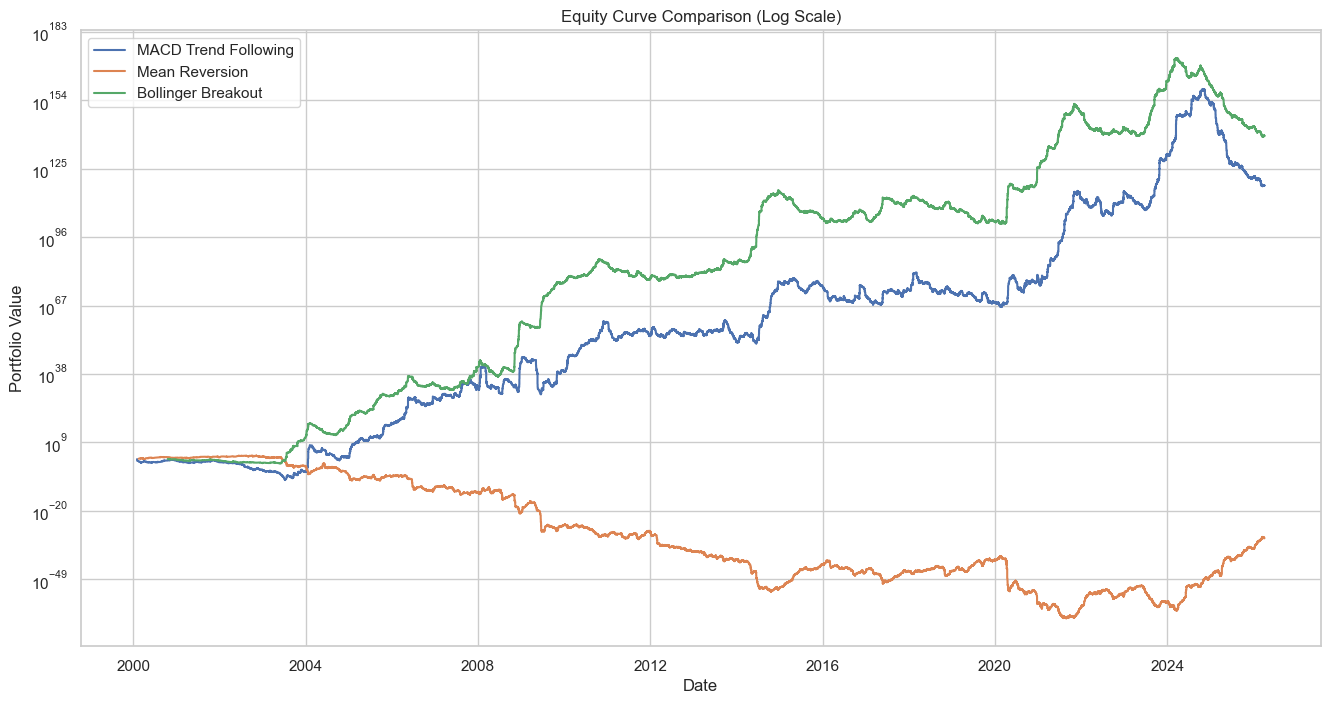

In [61]:
# ============================================================
# BLOCK 14.1
# EQUITY CURVES
# ============================================================

import matplotlib.pyplot as plt

def build_equity_curve(df):

    curve = df.copy()

    curve = curve.sort_values(
        "Exit Date"
    )

    curve["Equity"] = (

        100

        *

        (
            1
            +
            curve["Return %"] / 100
        ).cumprod()

    )

    return curve


macd_equity = build_equity_curve(
    macd_stop
)

mr_equity = build_equity_curve(
    mr_stop
)

breakout_equity = build_equity_curve(
    breakout_stop
)


plt.figure(figsize=(16,8))

plt.plot(
    macd_equity["Exit Date"],
    macd_equity["Equity"],
    label="MACD Trend Following"
)

plt.plot(
    mr_equity["Exit Date"],
    mr_equity["Equity"],
    label="Mean Reversion"
)

plt.plot(
    breakout_equity["Exit Date"],
    breakout_equity["Equity"],
    label="Bollinger Breakout"
)

plt.yscale("log")

plt.title(
    "Equity Curve Comparison (Log Scale)"
)

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.legend()

plt.grid(True)

plt.show()

In [62]:
print("\nFINAL EQUITY VALUES\n")

print(
    "MACD:",
    round(
        macd_equity["Equity"].iloc[-1],
        2
    )
)

print(
    "Mean Reversion:",
    round(
        mr_equity["Equity"].iloc[-1],
        2
    )
)

print(
    "Breakout:",
    round(
        breakout_equity["Equity"].iloc[-1],
        2
    )
)


FINAL EQUITY VALUES

MACD: 6.575015367978148e+117
Mean Reversion: 0.0
Breakout: 8.150525561554656e+138


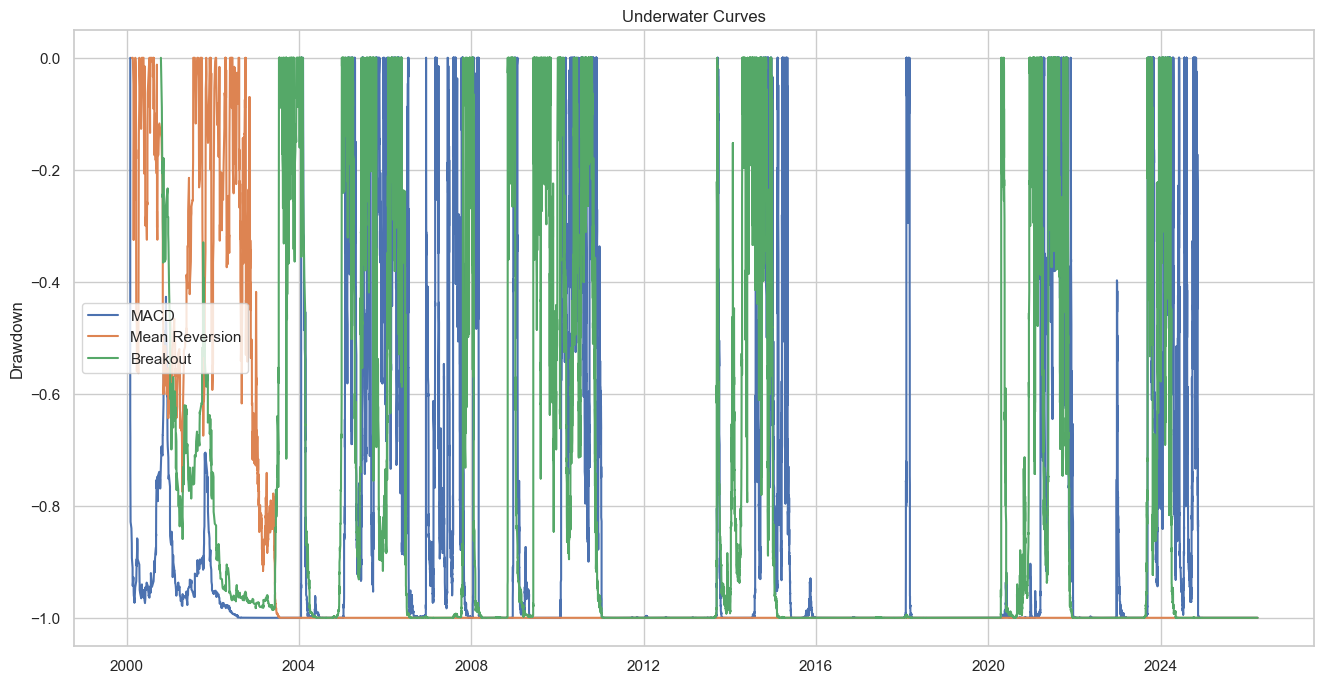

In [63]:
# ============================================================
# UNDERWATER CURVES
# ============================================================

def build_underwater_curve(df):

    curve = df.copy()

    curve = curve.sort_values(
        "Exit Date"
    )

    curve["Equity"] = (

        1

        *

        (
            1
            +
            curve["Return %"] / 100
        ).cumprod()

    )

    curve["Peak"] = (
        curve["Equity"]
        .cummax()
    )

    curve["Drawdown"] = (

        curve["Equity"]
        /
        curve["Peak"]

        - 1

    )

    return curve


macd_dd = build_underwater_curve(
    macd_stop
)

mr_dd = build_underwater_curve(
    mr_stop
)

breakout_dd = build_underwater_curve(
    breakout_stop
)


plt.figure(figsize=(16,8))

plt.plot(
    macd_dd["Exit Date"],
    macd_dd["Drawdown"],
    label="MACD"
)

plt.plot(
    mr_dd["Exit Date"],
    mr_dd["Drawdown"],
    label="Mean Reversion"
)

plt.plot(
    breakout_dd["Exit Date"],
    breakout_dd["Drawdown"],
    label="Breakout"
)

plt.title(
    "Underwater Curves"
)

plt.ylabel(
    "Drawdown"
)

plt.legend()

plt.grid(True)

plt.show()

In [64]:
print(
    "MACD MDD:",
    round(
        macd_dd["Drawdown"].min()*100,
        2
    ),
    "%"
)

print(
    "MR MDD:",
    round(
        mr_dd["Drawdown"].min()*100,
        2
    ),
    "%"
)

print(
    "Breakout MDD:",
    round(
        breakout_dd["Drawdown"].min()*100,
        2
    ),
    "%"
)

MACD MDD: -100.0 %
MR MDD: -100.0 %
Breakout MDD: -100.0 %


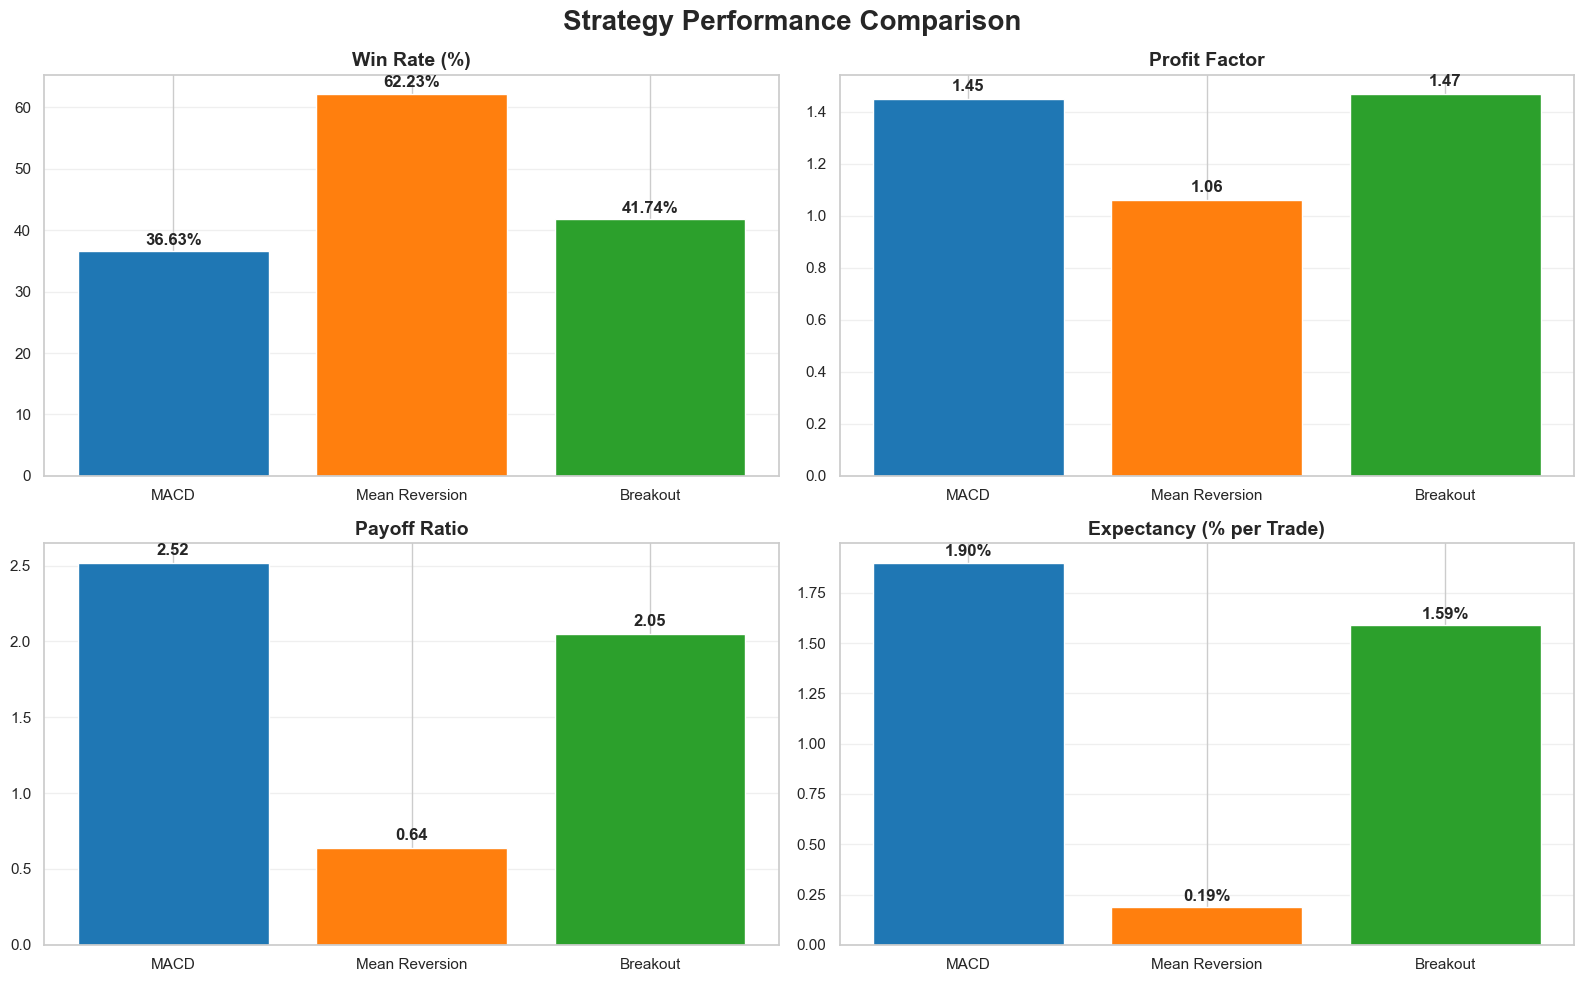

In [66]:
# ============================================================
# INSTITUTIONAL STRATEGY DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

comparison_metrics = pd.DataFrame({

    "Strategy": [
        "MACD",
        "Mean Reversion",
        "Breakout"
    ],

    "Win Rate": [
        36.63,
        62.23,
        41.74
    ],

    "Profit Factor": [
        1.45,
        1.06,
        1.47
    ],

    "Payoff Ratio": [
        2.52,
        0.64,
        2.05
    ],

    "Expectancy": [
        1.90,
        0.19,
        1.59
    ]

})

# ------------------------------------------------------------
# COLORS
# ------------------------------------------------------------

strategy_colors = [

    "#1f77b4",   # MACD = Blue
    "#ff7f0e",   # Mean Reversion = Orange
    "#2ca02c"    # Breakout = Green

]

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

fig.suptitle(
    "Strategy Performance Comparison",
    fontsize=20,
    fontweight="bold"
)

# ============================================================
# WIN RATE
# ============================================================

bars = axes[0,0].bar(
    comparison_metrics["Strategy"],
    comparison_metrics["Win Rate"],
    color=strategy_colors
)

axes[0,0].set_title(
    "Win Rate (%)",
    fontsize=14,
    fontweight="bold"
)

axes[0,0].grid(
    alpha=0.3,
    axis="y"
)

for bar in bars:

    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontweight="bold"
    )

# ============================================================
# PROFIT FACTOR
# ============================================================

bars = axes[0,1].bar(
    comparison_metrics["Strategy"],
    comparison_metrics["Profit Factor"],
    color=strategy_colors
)

axes[0,1].set_title(
    "Profit Factor",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].grid(
    alpha=0.3,
    axis="y"
)

for bar in bars:

    axes[0,1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.03,
        f"{bar.get_height():.2f}",
        ha="center",
        fontweight="bold"
    )

# ============================================================
# PAYOFF RATIO
# ============================================================

bars = axes[1,0].bar(
    comparison_metrics["Strategy"],
    comparison_metrics["Payoff Ratio"],
    color=strategy_colors
)

axes[1,0].set_title(
    "Payoff Ratio",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].grid(
    alpha=0.3,
    axis="y"
)

for bar in bars:

    axes[1,0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.05,
        f"{bar.get_height():.2f}",
        ha="center",
        fontweight="bold"
    )

# ============================================================
# EXPECTANCY
# ============================================================

bars = axes[1,1].bar(
    comparison_metrics["Strategy"],
    comparison_metrics["Expectancy"],
    color=strategy_colors
)

axes[1,1].set_title(
    "Expectancy (% per Trade)",
    fontsize=14,
    fontweight="bold"
)

axes[1,1].grid(
    alpha=0.3,
    axis="y"
)

for bar in bars:

    axes[1,1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.03,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontweight="bold"
    )

# ------------------------------------------------------------
# CLEANUP
# ------------------------------------------------------------

for ax in axes.flatten():

    ax.set_xlabel("")
    ax.tick_params(
        axis="x",
        rotation=0
    )

plt.tight_layout()

plt.show()

In [67]:
MACD_COLOR      = "#1f77b4"   # Blue
MR_COLOR        = "#ff7f0e"   # Orange
BREAKOUT_COLOR  = "#2ca02c"   # Green

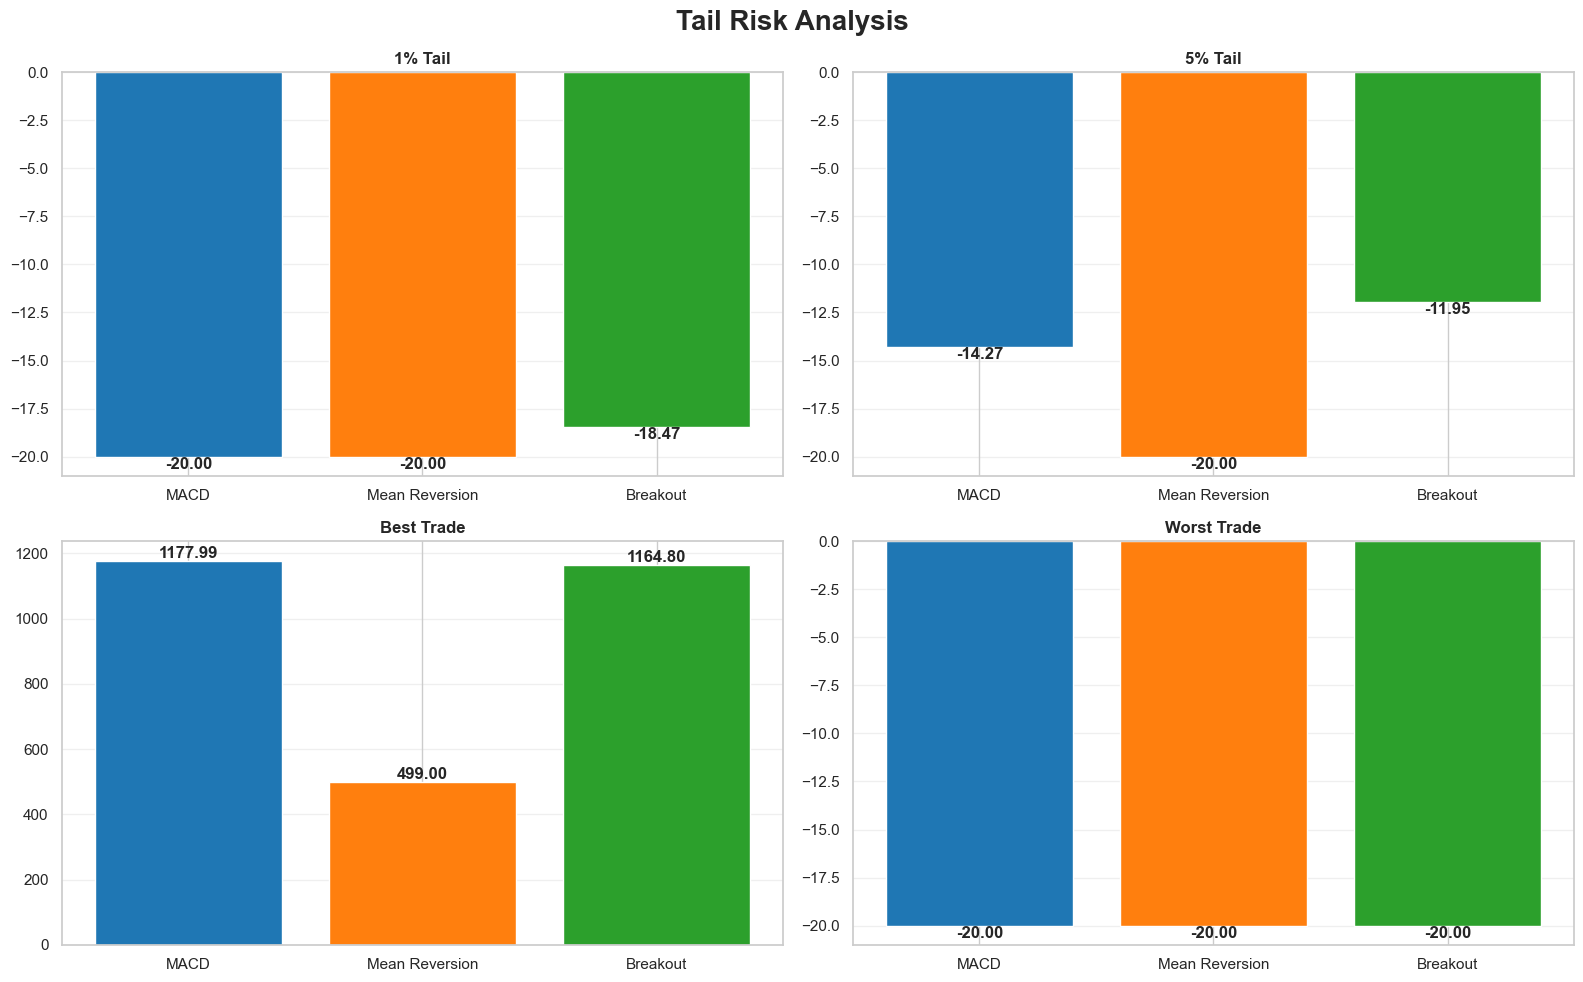

In [68]:
# ============================================================
# TAIL RISK DASHBOARD
# ============================================================

tail_risk = pd.DataFrame({

    "Strategy": [
        "MACD",
        "Mean Reversion",
        "Breakout"
    ],

    "1% Tail": [
        -20.00,
        -20.00,
        -18.47
    ],

    "5% Tail": [
        -14.27,
        -20.00,
        -11.95
    ],

    "Best Trade": [
        1177.99,
        499.00,
        1164.80
    ],

    "Worst Trade": [
        -20.00,
        -20.00,
        -20.00
    ]

})

colors = [
    MACD_COLOR,
    MR_COLOR,
    BREAKOUT_COLOR
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

fig.suptitle(
    "Tail Risk Analysis",
    fontsize=20,
    fontweight="bold"
)

metrics = [

    ("1% Tail", axes[0,0]),
    ("5% Tail", axes[0,1]),
    ("Best Trade", axes[1,0]),
    ("Worst Trade", axes[1,1])

]

for metric, ax in metrics:

    bars = ax.bar(
        tail_risk["Strategy"],
        tail_risk[metric],
        color=colors
    )

    ax.set_title(
        metric,
        fontweight="bold"
    )

    ax.grid(
        alpha=0.3,
        axis="y"
    )

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom" if height > 0 else "top",
            fontweight="bold"
        )

plt.tight_layout()

plt.show()

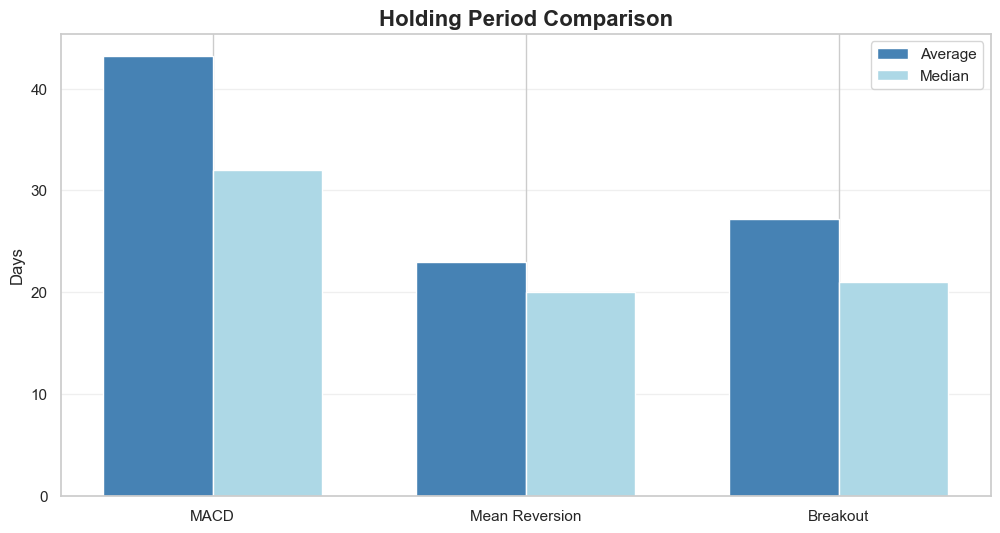

In [69]:
# ============================================================
# HOLDING PERIOD COMPARISON
# ============================================================

holding_df = pd.DataFrame({

    "Strategy": [
        "MACD",
        "Mean Reversion",
        "Breakout"
    ],

    "Average Hold": [
        43.23,
        22.96,
        27.19
    ],

    "Median Hold": [
        32,
        20,
        21
    ]

})

x = np.arange(len(holding_df))

width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    holding_df["Average Hold"],
    width,
    label="Average",
    color="steelblue"
)

plt.bar(
    x + width/2,
    holding_df["Median Hold"],
    width,
    label="Median",
    color="lightblue"
)

plt.xticks(
    x,
    holding_df["Strategy"]
)

plt.title(
    "Holding Period Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Days"
)

plt.legend()

plt.grid(
    alpha=0.3,
    axis="y"
)

plt.show()

In [70]:
# ============================================================
# FINAL SCORECARD
# ============================================================

scorecard = comparison_stop.T[[
    "Win Rate %",
    "Profit Factor",
    "Payoff Ratio",
    "Expectancy %",
    "Avg Hold Days"
]]

display(
    scorecard.style
    .background_gradient(
        cmap="RdYlGn"
    )
    .format("{:.2f}")
)

,Win Rate %,Profit Factor,Payoff Ratio,Expectancy %,Avg Hold Days
MACD,36.63,1.45,2.52,1.90,43.23
Mean Reversion,62.23,1.06,0.64,0.19,22.96
Breakout,41.74,1.47,2.05,1.59,27.19


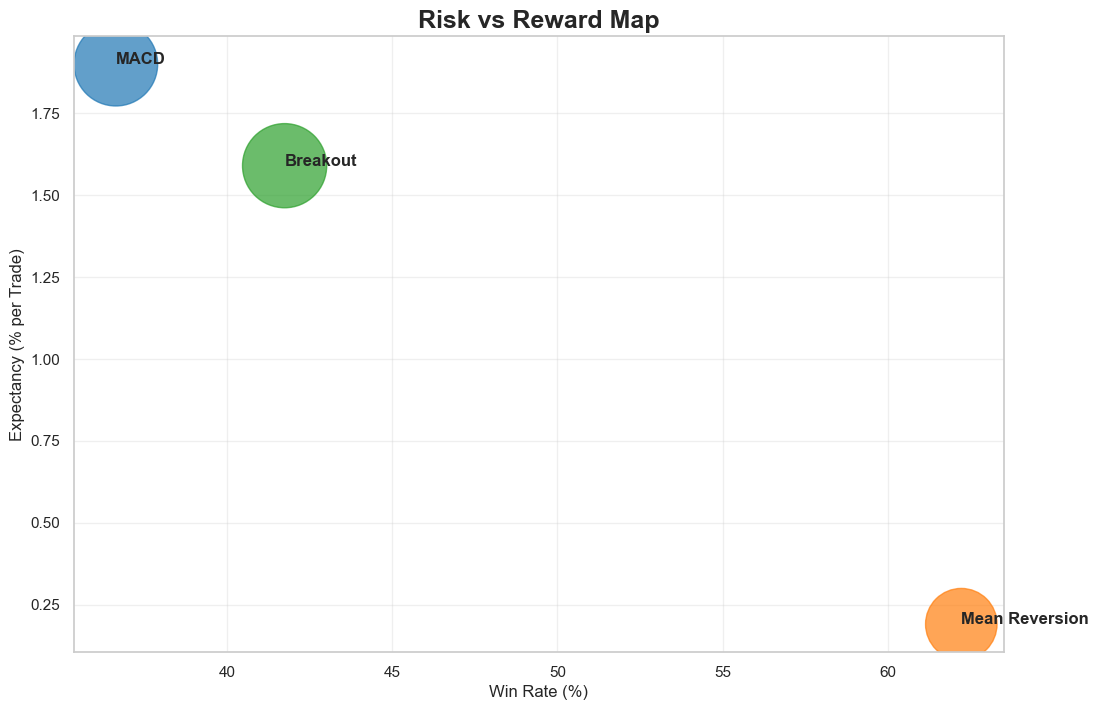

In [71]:
# ============================================================
# RISK REWARD MAP
# ============================================================

plt.figure(figsize=(12,8))

strategies = ["MACD", "Mean Reversion", "Breakout"]

win_rate = [
    36.63,
    62.23,
    41.74
]

expectancy = [
    1.90,
    0.19,
    1.59
]

profit_factor = [
    1.45,
    1.06,
    1.47
]

colors = [
    MACD_COLOR,
    MR_COLOR,
    BREAKOUT_COLOR
]

sizes = [
    pf * 2500
    for pf in profit_factor
]

plt.scatter(
    win_rate,
    expectancy,
    s=sizes,
    c=colors,
    alpha=0.7
)

for i, strategy in enumerate(strategies):

    plt.annotate(
        strategy,
        (
            win_rate[i],
            expectancy[i]
        ),
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Risk vs Reward Map",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Win Rate (%)"
)

plt.ylabel(
    "Expectancy (% per Trade)"
)

plt.grid(alpha=0.3)

plt.show()